In [1]:
!pip install openml xgboost lightgbm -q

import os
import json
import random
import warnings
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score
import openml


warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass


PROJECT = '/content/drive/MyDrive/tabssl_project_new_4'

for f in ['src', 'scripts', 'configs', 'results', 'plots', 'paper', 'data/cache']:
    os.makedirs(f'{PROJECT}/{f}', exist_ok=True)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.6 MB/s eta 0:00:00
Mounted at /content/drive
Using device: cpu


In [ ]:
def load_openml_task(task_id, fold=0, verbose=True):

    task = openml.tasks.get_task(task_id)
    dataset = task.get_dataset()
    X, y, cat_indicator, _ = dataset.get_data(dataset_format='dataframe', target=task.target_name)

    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    train_idx, test_idx = task.get_train_test_split_indices(fold=fold)
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test  = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].values.ravel()
    y_test  = y.iloc[test_idx].values.ravel()


    le = LabelEncoder()
    y_train = le.fit_transform(y_train.astype(str))
    y_test  = le.transform(y_test.astype(str))
    n_classes = len(le.classes_)

    if verbose:
        n_num_v = sum(1 for c in cat_indicator if not c)
        n_cat_v = sum(c for c in cat_indicator)
        print(f"Task {task_id}: {dataset.name} | Train: {len(X_train)} | Test: {len(X_test)} | Classes: {n_classes}")
        print(f"Numeric: {n_num_v} | Categorical: {n_cat_v} | Missing: {X_train.isnull().mean().mean()*100:.1f}%")


    return X_train, X_test, y_train, y_test, cat_indicator, n_classes



class TabularPreprocessor:
    def __init__(self, cat_indicator):
        self.cat_indicator = cat_indicator
        self.num_cols = [i for i, c in enumerate(cat_indicator) if not c]
        self.cat_cols = [i for i, c in enumerate(cat_indicator) if c]
        self.n_num = len(self.num_cols)
        self.n_cat = len(self.cat_cols)
        self.cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.cat_sizes = []
        self.fitted = False

    def fit(self, X_df):
        if self.n_num > 0:
            raw = X_df.iloc[:, self.num_cols].values.astype(float)
            means, stds = [], []
            for j in range(raw.shape[1]):
                col = raw[:, j]
                valid = col[~np.isnan(col)]
                means.append(valid.mean() if len(valid) > 0 else 0.0)
                stds.append(valid.std() if len(valid) > 1 else 1.0)
            self.means = np.array(means)
            self.stds  = np.where(np.array(stds) < 1e-8, 1.0, np.array(stds))

        if self.n_cat > 0:
            raw_cat = X_df.iloc[:, self.cat_cols].astype(str)
            self.cat_encoder.fit(raw_cat)
            self.cat_sizes = [len(cats) + 2 for cats in self.cat_encoder.categories_]

        self.fitted = True
        return self


    def transform(self, X_df):
        assert self.fitted
        n = len(X_df)
        if self.n_num > 0:
            raw = X_df.iloc[:, self.num_cols].values.astype(float)
            M_num = np.isnan(raw).astype(np.float32)
            X_num = np.where(np.isnan((raw - self.means) / self.stds), 0.0, (raw - self.means) / self.stds).astype(np.float32)
        else:
            X_num, M_num = np.zeros((n, 0), dtype=np.float32), np.zeros((n, 0), dtype=np.float32)

        if self.n_cat > 0:
            raw_cat = X_df.iloc[:, self.cat_cols].astype(str)
            M_cat = raw_cat.isin(['nan', 'None', '<NA>', '']).values.astype(np.float32)
            enc = self.cat_encoder.transform(raw_cat)
            enc = np.where(enc < 0, 0, enc + 2).astype(np.int64)
        else:
            enc, M_cat = np.zeros((n, 0), dtype=np.int64), np.zeros((n, 0), dtype=np.float32)

        return X_num, M_num, enc, M_cat


    def fit_transform(self, X_df):
        return self.fit(X_df).transform(X_df)


class TabularDataset(Dataset):

    def __init__(self, X_num, M_num, X_cat, M_cat, y=None):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.M_num = torch.tensor(M_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.M_cat = torch.tensor(M_cat, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None

    def __len__(self): return len(self.X_num)

    def __getitem__(self, idx):
        item = {'x_num': self.X_num[idx], 'm_num': self.M_num[idx], 'x_cat': self.X_cat[idx], 'm_cat': self.M_cat[idx]}
        if self.y is not None: item['y'] = self.y[idx]
        return item

In [ ]:
def discover_feature_groups(X_num, n_groups=None):

    if X_num.shape[1] < 2: return [[i] for i in range(X_num.shape[1])]

    corr = pd.DataFrame(X_num).corr(method='spearman').fillna(0).abs().values
    np.fill_diagonal(corr, 1.0)
    dist = np.clip(1 - corr, 0, None)
    np.fill_diagonal(dist, 0)

    Z = linkage(squareform(dist, checks=False), method='average')

    if n_groups is None: n_groups = max(2, X_num.shape[1] // 3)

    labels = fcluster(Z, t=n_groups, criterion='maxclust')
    groups = {}

    for feat_idx, gid in enumerate(labels):
        groups.setdefault(gid, []).append(feat_idx)

    return list(groups.values())

def create_masked_views(x_num, m_num, x_cat, m_cat, mask_rate=0.3, feature_groups=None, group_mask_prob=0.5, device='cpu'):

    results = []
    for _ in range(2):
        ssl_mask_num, v_num = torch.zeros_like(m_num), x_num.clone()

        if x_num.shape[1] > 0:
            available = (m_num == 0)
            rand_mask = torch.bernoulli(torch.full_like(v_num, mask_rate)).bool() & available.bool()

            if feature_groups and x_num.shape[1] > 1:
                do_group = torch.rand(x_num.shape[0]) < group_mask_prob

                for b in range(x_num.shape[0]):
                    if do_group[b]:
                        g = feature_groups[torch.randint(len(feature_groups),(1,)).item()]

                        for f in [f for f in g if f < x_num.shape[1]]:
                            if available[b, f]: rand_mask[b, f] = True


            v_num[rand_mask] = 0.0
            ssl_mask_num = rand_mask.float()

        ssl_mask_cat, v_cat = torch.zeros_like(m_cat), x_cat.clone()


        if x_cat.shape[1] > 0:
            available_cat = (m_cat == 0)
            rand_mask_cat = torch.bernoulli(torch.full(m_cat.shape, mask_rate)).bool().to(device) & available_cat.bool()
            v_cat[rand_mask_cat] = 1
            ssl_mask_cat = rand_mask_cat.float()

        results.append({'v_num': v_num, 'v_cat': v_cat, 'ssl_mask_num': ssl_mask_num, 'ssl_mask_cat': ssl_mask_cat})

    return results[0], results[1]



class TabularEncoder(nn.Module):
    def __init__(self, n_num, cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128, dropout=0.1):

        super().__init__()
        self.n_num, self.n_cat, self.out_dim = n_num, len(cat_sizes), out_dim
        self.num_branch = nn.Sequential(nn.Linear(n_num * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
                                        nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU()) if n_num > 0 else None


        if self.n_cat > 0:

            self.cat_embeddings = nn.ModuleList([nn.Embedding(size, embed_dim, padding_idx=0) for size in cat_sizes])
            self.cat_branch = nn.Sequential(nn.Linear(self.n_cat * embed_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout))

        else:

            self.cat_embeddings, self.cat_branch = None, None

        num_out, cat_out = (hidden_dim if n_num > 0 else 0), (hidden_dim if self.n_cat > 0 else 0)
        self.fusion = nn.Sequential(nn.Linear(num_out + cat_out, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
                                    nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim))


    def forward(self, x_num, m_num, x_cat, m_cat):
        parts = []
        if self.num_branch: parts.append(self.num_branch(torch.cat([x_num, m_num], dim=1)))
        if self.cat_branch: parts.append(self.cat_branch(torch.cat([self.cat_embeddings[j](x_cat[:, j]) for j in range(self.n_cat)], dim=1)))
        return self.fusion(torch.cat(parts, dim=1))



class SSLDecoderHeads(nn.Module):

    def __init__(self, z_dim, n_num, cat_sizes, hidden_dim=128):
        super().__init__()
        self.numeric_head = nn.Sequential(nn.Linear(z_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, n_num)) if n_num > 0 else None
        self.cat_heads = nn.ModuleList([nn.Linear(z_dim, size) for size in cat_sizes]) if len(cat_sizes) > 0 else None


    def forward(self, z):
        return (self.numeric_head(z) if self.numeric_head else None, [h(z) for h in self.cat_heads] if self.cat_heads else [])



class ClassificationHead(nn.Module):
    def __init__(self, z_dim, n_classes, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes))

    def forward(self, z): return self.net(z)


def ssl_loss(z1, z2, n1, n2, c1, c2, xn, xc, smn1, smn2, smc1, smc2, consistency_weight=1.0):
    total = torch.tensor(0.0, device=z1.device)

    for num_preds, cat_logits, smn, smc in [(n1, c1, smn1, smc1), (n2, c2, smn2, smc2)]:
        rec, n_terms = torch.tensor(0.0, device=z1.device), 0

        if num_preds is not None and smn.sum() > 0:
            rec += (((num_preds - xn) ** 2) * smn).sum() / (smn.sum() + 1e-8)
            n_terms += 1

        if cat_logits and smc.sum() > 0:
            cat_rec, n_ct = torch.tensor(0.0, device=z1.device), 0

            for j, logits_j in enumerate(cat_logits):
                mask_j = smc[:, j].bool()
                if mask_j.sum() > 0:
                    ce = F.cross_entropy(logits_j[mask_j], xc[:, j][mask_j])
                    if not torch.isnan(ce): cat_rec += ce; n_ct += 1

            if n_ct > 0: rec += cat_rec / n_ct; n_terms += 1

        total += rec / max(n_terms, 1)

    L_cons = (1 - F.cosine_similarity(z1, z2, dim=1)).mean()
    return total + consistency_weight * L_cons

In [ ]:
def pretrain(encoder, decoder, train_dataset, n_epochs=50, batch_size=256, lr=1e-3, mask_rate=0.3, feature_groups=None, device='cuda', save_path=None, pbar=None, mask_aware=False):
    encoder.train(); decoder.train()
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    if len(loader) == 0: loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=n_epochs * max(len(loader), 1), pct_start=0.1)



    for epoch in range(n_epochs):
        epoch_loss = 0.0

        for batch in loader:

            xn, mn, xc, mc = batch['x_num'].to(device), batch['m_num'].to(device), batch['x_cat'].to(device), batch['m_cat'].to(device)
            v1, v2 = create_masked_views(xn, mn, xc, mc, mask_rate=mask_rate, feature_groups=feature_groups, device=device)

            if mask_aware:

                m1_num = torch.clamp(mn + v1['ssl_mask_num'], 0, 1)
                m2_num = torch.clamp(mn + v2['ssl_mask_num'], 0, 1)
                m1_cat = torch.clamp(mc + v1['ssl_mask_cat'], 0, 1)
                m2_cat = torch.clamp(mc + v2['ssl_mask_cat'], 0, 1)

            else:
                m1_num = m2_num = mn
                m1_cat = m2_cat = mc


            z1, z2 = encoder(v1['v_num'], m1_num, v1['v_cat'], m1_cat), encoder(v2['v_num'], m2_num, v2['v_cat'], m2_cat)
            n1, c1 = decoder(z1)
            n2, c2 = decoder(z2)

            loss = ssl_loss(z1, z2, n1, n2, c1, c2, xn, xc, v1['ssl_mask_num'], v2['ssl_mask_num'], v1['ssl_mask_cat'], v2['ssl_mask_cat'])
            optimizer.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(params, 1.0); optimizer.step(); scheduler.step()
            epoch_loss += loss.item()


        if pbar and (epoch + 1) % 10 == 0:
            pbar.write(f"      - Pretrain Epoch {epoch+1}/{n_epochs} | Loss: {epoch_loss/len(loader):.4f}")


    if save_path:
        torch.save({'encoder_state': encoder.state_dict(), 'decoder_state': decoder.state_dict()}, save_path)



def finetune_and_evaluate(encoder_init, pretrained_path, train_dataset, test_dataset, y_train_full, n_classes, ep_params, label_fractions=[0.01, 0.05, 0.10, 0.20], n_seeds=3, device='cuda'):
    results = {frac: [] for frac in label_fractions}

    for frac in label_fractions:

        for seed in range(n_seeds):
            set_seed(seed)
            n_labeled = max(int(len(y_train_full) * frac), n_classes)
            idx, _ = next(StratifiedShuffleSplit(1, train_size=n_labeled, random_state=seed).split(np.zeros(len(y_train_full)), y_train_full))

            labeled_loader = DataLoader(torch.utils.data.Subset(train_dataset, idx), batch_size=min(128, n_labeled), shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

            enc = TabularEncoder(**ep_params).to(device)

            if encoder_init == 'pretrained':
                enc.load_state_dict(torch.load(pretrained_path, map_location=device)['encoder_state'])
            head = ClassificationHead(128, n_classes).to(device)
            optimizer = torch.optim.AdamW(list(enc.parameters()) + list(head.parameters()), lr=1e-3, weight_decay=1e-4)

            enc.train(); head.train()


            for _ in range(30):
                for b in labeled_loader:
                    loss = F.cross_entropy(head(enc(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))), b['y'].to(device))
                    optimizer.zero_grad(); loss.backward(); optimizer.step()


            enc.eval(); head.eval()
            all_probs, all_labels = [], []

            with torch.no_grad():

                for b in test_loader:
                    probs = F.softmax(head(enc(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))), dim=1)
                    all_probs.append(probs.cpu().numpy())

                    all_labels.append(b['y'].numpy())


            all_probs, all_labels = np.concatenate(all_probs), np.concatenate(all_labels)

            auc = roc_auc_score(all_labels, all_probs[:, 1]) if n_classes == 2 else roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
            results[frac].append(auc)

    return results



def robustness_eval(enc, head, Xn, Mn, Xc, Mc, y, n_cls, device):

    def get_auc(Xn_, Mn_, Xc_=Xc, Mc_=Mc):
        ds = TabularDataset(Xn_, Mn_, Xc_, Mc_, y)

        ld = DataLoader(ds, batch_size=256, shuffle=False)
        pp, ll = [], []

        with torch.no_grad():
            for b in ld:
                pp.append(F.softmax(head(enc(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))), dim=1).cpu().numpy())
                ll.append(b['y'].numpy())
        pp, ll = np.concatenate(pp), np.concatenate(ll)

        return roc_auc_score(ll, pp[:, 1]) if n_cls == 2 else roc_auc_score(ll, pp, multi_class='ovr', average='macro')

    auc_normal = get_auc(Xn, Mn)


    rng = np.random.RandomState(0)
    Xn_mcar, Mn_mcar = Xn.copy(), Mn.copy()

    mask_mcar = (rng.rand(*Xn.shape) < 0.3) & (Mn == 0)
    Xn_mcar[mask_mcar], Mn_mcar[mask_mcar] = 0.0, 1.0

    Xc_mcar, Mc_mcar = Xc.copy(), Mc.copy()

    if Xc.shape[1] > 0:

        mask_mcar_cat = (rng.rand(*Xc.shape) < 0.3) & (Mc == 0)
        Xc_mcar[mask_mcar_cat], Mc_mcar[mask_mcar_cat] = 1, 1.0


    auc_mcar = get_auc(Xn_mcar, Mn_mcar, Xc_mcar, Mc_mcar)


    Xn_shift, Mn_shift = Xn.copy(), Mn.copy()
    mask_shift = (Xn > np.percentile(Xn, 70, axis=0)) & (Mn == 0)
    Xn_shift[mask_shift], Mn_shift[mask_shift] = 0.0, 1.0
    auc_shift = get_auc(Xn_shift, Mn_shift)

    return auc_normal, auc_mcar, auc_shift

In [ ]:
# Robustness evaluation (normal/MCAR/MNAR) is not done here.
# It runs in a later cell using build_eval_model_fixed, which uses the
# correct weight_decay=1e-4. Results are saved to results/robustness_fixed.json.

from tqdm.auto import tqdm
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit


def run_one_task(tid, device, pbar=None):

    save_dir = f'{PROJECT}/results/task_{tid}'
    os.makedirs(save_dir, exist_ok=True)


    if os.path.exists(f'{save_dir}/results.json'):
        if pbar: pbar.write(f"  Task {tid}: Already done, loading from cache.")
        with open(f'{save_dir}/results.json') as f: return json.load(f)


    try:
        X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task(tid, verbose=False)

    except Exception as e:
        if pbar: pbar.write(f"  Task {tid} ERROR: {e}")
        return None


    if len(X_tr) < 300:

        if pbar: pbar.write(f"  Task {tid} SKIP: Too few samples ({len(X_tr)} < 300).")
        return None


    if pbar: pbar.write(f"  Task {tid}: Preprocessing...")

    p = TabularPreprocessor(cat_ind)
    Xn_tr, Mn_tr, Xc_tr, Mc_tr = p.fit_transform(X_tr)
    Xn_te, Mn_te, Xc_te, Mc_te = p.transform(X_te)
    tr_ds = TabularDataset(Xn_tr, Mn_tr, Xc_tr, Mc_tr, y_tr)
    te_ds = TabularDataset(Xn_te, Mn_te, Xc_te, Mc_te, y_te)


    ep = dict(n_num=Xn_tr.shape[1], cat_sizes=p.cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128)
    fg = discover_feature_groups(Xn_tr) if Xn_tr.shape[1] >= 2 else None



    if pbar: pbar.write(f"  Task {tid}: SSL Pretraining...")

    enc = TabularEncoder(**ep).to(device)
    dec = SSLDecoderHeads(128, Xn_tr.shape[1], p.cat_sizes).to(device)
    ppath = f'{save_dir}/pretrained.pt'
    pretrain(enc, dec, tr_ds, feature_groups=fg, device=device, save_path=ppath, pbar=pbar)


    if pbar: pbar.write(f"  Task {tid}: Fine-tuning (SSL vs Scratch)...")
    res_pre = finetune_and_evaluate('pretrained', ppath, tr_ds, te_ds, y_tr, n_cls, ep, device=device)
    res_scr = finetune_and_evaluate('scratch', ppath, tr_ds, te_ds, y_tr, n_cls, ep, device=device)


    task_res = {

        'task_id': tid, 'n_train': len(X_tr), 'missing_pct': float(Mn_tr.mean() * 100),
        'pretrained': {str(k): [float(v) for v in vs] for k, vs in res_pre.items()},
        'scratch': {str(k): [float(v) for v in vs] for k, vs in res_scr.items()},
    }


    with open(f'{save_dir}/results.json', 'w') as f: json.dump(task_res, f, indent=2)

    if pbar: pbar.write(f"Task {tid} completed successfully.\n")
    return task_res



TASK_LIST = [2079, 3021, 14954, 146800, 2, 15, 29, 3904, 7592, 6, 32, 37, 43, 53]

all_results = {}

pbar = tqdm(TASK_LIST, desc="Processing Datasets")

for tid in pbar:

    pbar.set_postfix({'Current Task': tid})
    res = run_one_task(tid, device, pbar)
    if res:
        all_results[tid] = res


Processing Datasets:   0%|          | 0/14 [00:00<?, ?it/s]

  Task 2079: Already done, loading from cache.
  Task 3021: Already done, loading from cache.
  Task 14954: Already done, loading from cache.
  Task 146800: Already done, loading from cache.
  Task 2: Already done, loading from cache.
  Task 15: Already done, loading from cache.
  Task 29: Already done, loading from cache.
  Task 3904: Already done, loading from cache.
  Task 7592: Already done, loading from cache.
  Task 6: Already done, loading from cache.
  Task 32: Already done, loading from cache.
  Task 37: Already done, loading from cache.
  Task 43: Already done, loading from cache.
  Task 53: Already done, loading from cache.


In [ ]:
import json
import torch
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

import os, pickle


def load_openml_task_cached(tid, cache_dir=f'{PROJECT}/cache/openml_tasks', **kwargs):

    os.makedirs(cache_dir, exist_ok=True)
    fpath = f'{cache_dir}/task_{tid}.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            return pickle.load(f)

    result = load_openml_task(tid, **kwargs)

    with open(fpath, 'wb') as f:
        pickle.dump(result, f)
    return result


print("Classical baselines (10% labels)")
baseline_results = {'LR': [], 'RF': [], 'XGB': [], 'LGBM': []}


for tid in TASK_LIST:

    X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task_cached(tid, verbose=False)

    set_seed(SEED)
    n_labeled = max(int(len(y_tr) * 0.10), n_cls)

    idx, _ = next(StratifiedShuffleSplit(1, train_size=n_labeled, random_state=SEED).split(np.zeros(len(y_tr)), y_tr))
    X_tr_lab, y_tr_lab = X_tr.iloc[idx], y_tr[idx]

    X_tr_lab_proc = X_tr_lab.copy()
    X_te_proc = X_te.copy()

    cat_cols = [X_tr_lab.columns[i] for i, c in enumerate(cat_ind) if c]
    num_cols = [X_tr_lab.columns[i] for i, c in enumerate(cat_ind) if not c]

    X_tr_full_num = X_tr.copy()

    for col in num_cols:

        X_tr_full_num[col] = pd.to_numeric(X_tr_full_num[col], errors='coerce')
        X_tr_lab_proc[col] = pd.to_numeric(X_tr_lab_proc[col], errors='coerce')
        X_te_proc[col] = pd.to_numeric(X_te_proc[col], errors='coerce')
        fill_val = X_tr_full_num[col].mean()

        if pd.isna(fill_val): fill_val = 0.0

        X_tr_lab_proc[col] = X_tr_lab_proc[col].fillna(fill_val)
        X_te_proc[col] = X_te_proc[col].fillna(fill_val)


    for col in cat_cols:

        if X_tr_lab_proc[col].dtype.name == 'category':
            X_tr_lab_proc[col] = X_tr_lab_proc[col].astype(object)
            X_te_proc[col] = X_te_proc[col].astype(object)

        modes = X_tr[col].mode()

        fill_val = modes.iloc[0] if not modes.empty else "missing"
        X_tr_lab_proc[col] = X_tr_lab_proc[col].fillna(fill_val)
        X_te_proc[col] = X_te_proc[col].fillna(fill_val)


    if cat_cols:

        X_tr_lab_proc[cat_cols] = X_tr_lab_proc[cat_cols].astype(str)
        X_te_proc[cat_cols] = X_te_proc[cat_cols].astype(str)

        X_tr_full_cat = X_tr[cat_cols].astype(str)
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        oe.fit(X_tr_full_cat)

        X_tr_lab_proc[cat_cols] = oe.transform(X_tr_lab_proc[cat_cols])
        X_te_proc[cat_cols] = oe.transform(X_te_proc[cat_cols])


    if num_cols:

        X_tr_lab_proc[num_cols] = X_tr_lab_proc[num_cols].astype(float)
        X_te_proc[num_cols] = X_te_proc[num_cols].astype(float)



    models = {
        'LR': LogisticRegression(max_iter=1000),
        'RF': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
        'XGB': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED, n_jobs=-1),
        'LGBM': LGBMClassifier(verbose=-1, random_state=SEED, n_jobs=-1)
    }


    for name, model in models.items():
        model.fit(X_tr_lab_proc, y_tr_lab)
        probs = model.predict_proba(X_te_proc)

        auc = roc_auc_score(y_te, probs[:, 1]) if n_cls == 2 else roc_auc_score(y_te, probs, multi_class='ovr', average='macro')
        baseline_results[name].append(auc)


print("Baseline Average AUC at 10% labels:")


for name, aucs in baseline_results.items():
    print(f"  {name}: {np.mean(aucs):.4f}")

ssl_10_avg = np.mean([np.mean(r['pretrained']['0.1']) for r in all_results.values()])

scr_10_avg = np.mean([np.mean(r['scratch']['0.1']) for r in all_results.values()])

print(f"SSL Pretrained @ 10% labels (avg over {len(all_results)} tasks): {ssl_10_avg:.4f}")

print(f"Scratch @ 10% labels (avg over {len(all_results)} tasks): {scr_10_avg:.4f}")


print("\nAblation study (native-missingness tasks 3021, 2079, 14954, 146800; 10% labels)")
print("    (averaged over 3 independent pretraining seeds per variant, matching n_seeds=3 elsewhere)")


ablation_tasks = [3021, 2079, 14954, 146800]
PRETRAIN_SEEDS = [SEED, SEED + 1, SEED + 2]



variants = [
    ('full', True, 1.0, False),
    ('no_consistency', True, 0.0, False),
    ('no_group_mask', False, 1.0, False),
    ('mask_aware', True, 1.0, True),
]


ablation_results = {tid: {v_name: [] for v_name, *_ in variants} for tid in ablation_tasks}
ablation_raw = {tid: {v_name: [] for v_name, *_ in variants} for tid in ablation_tasks}



for tid in ablation_tasks:
    X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task_cached(tid, verbose=False)
    set_seed(SEED)
    p = TabularPreprocessor(cat_ind)
    Xn_tr, Mn_tr, Xc_tr, Mc_tr = p.fit_transform(X_tr)

    Xn_te, Mn_te, Xc_te, Mc_te = p.transform(X_te)
    tr_ds = TabularDataset(Xn_tr, Mn_tr, Xc_tr, Mc_tr, y_tr)
    te_ds = TabularDataset(Xn_te, Mn_te, Xc_te, Mc_te, y_te)

    ep = dict(n_num=Xn_tr.shape[1], cat_sizes=p.cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128)

    fg = discover_feature_groups(Xn_tr) if Xn_tr.shape[1] >= 2 else None



    for v_name, v_use_fg, v_cons, v_mask_aware in variants:
        v_fg = fg if v_use_fg else None


        for p_seed in PRETRAIN_SEEDS:

            set_seed(p_seed)
            enc = TabularEncoder(**ep).to(device)

            dec = SSLDecoderHeads(128, Xn_tr.shape[1], p.cat_sizes).to(device)

            old_loss = ssl_loss


            def custom_loss(*args, **kwargs): return old_loss(*args, consistency_weight=v_cons, **kwargs)
            globals()['ssl_loss'] = custom_loss

            pretrain(enc, dec, tr_ds, feature_groups=v_fg, device=device, mask_aware=v_mask_aware)
            globals()['ssl_loss'] = old_loss

            torch.save({'encoder_state': enc.state_dict()}, 'tmp_ablation.pt')
            res = finetune_and_evaluate('pretrained', 'tmp_ablation.pt', tr_ds, te_ds, y_tr, n_cls, ep, label_fractions=[0.10], n_seeds=3, device=device)


            seed_auc = np.mean(res[0.10])

            ablation_raw[tid][v_name].append(seed_auc)

            print(f"  Task {tid} | {v_name} | pretrain_seed={p_seed}: {seed_auc:.4f}")

        ablation_results[tid][v_name] = float(np.mean(ablation_raw[tid][v_name]))
        ablation_std = float(np.std(ablation_raw[tid][v_name]))

        print(f"  Task {tid} | {v_name} | MEAN over {len(PRETRAIN_SEEDS)} seeds: {ablation_results[tid][v_name]:.4f} (std {ablation_std:.4f})")




print("\nRobustness degradation curve (Task 3021)")

tid = 3021

X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task_cached(tid, verbose=False)
p = TabularPreprocessor(cat_ind)
Xn_tr, Mn_tr, Xc_tr, Mc_tr = p.fit_transform(X_tr)

Xn_te, Mn_te, Xc_te, Mc_te = p.transform(X_te)
tr_ds = TabularDataset(Xn_tr, Mn_tr, Xc_tr, Mc_tr, y_tr)

ep = dict(n_num=Xn_tr.shape[1], cat_sizes=p.cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128)


ppath_3021 = f'{PROJECT}/results/task_{tid}/pretrained.pt'


def build_trained_model(encoder_init):
    set_seed(SEED)
    enc = TabularEncoder(**ep).to(device)

    if encoder_init == 'pretrained':
        enc.load_state_dict(torch.load(ppath_3021, map_location=device)['encoder_state'])

    head = ClassificationHead(128, n_cls).to(device)
    n_lab = max(int(len(y_tr) * 0.10), n_cls)
    idx, _ = next(StratifiedShuffleSplit(1, train_size=n_lab, random_state=SEED).split(np.zeros(len(y_tr)), y_tr))

    ld = DataLoader(torch.utils.data.Subset(tr_ds, idx), batch_size=min(128, n_lab), shuffle=True)
    opt = torch.optim.AdamW(list(enc.parameters()) + list(head.parameters()), lr=1e-3, weight_decay=1e-4)
    enc.train(); head.train()


    for _ in range(30):

        for b in ld:
            loss = F.cross_entropy(head(enc(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))), b['y'].to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    enc.eval(); head.eval()
    return enc, head


e_p, h_p = build_trained_model('pretrained')
e_s, h_s = build_trained_model('scratch')



def get_auc_at_rate(enc, head, r):
    rng = np.random.RandomState(0)

    Xn_m, Mn_m = Xn_te.copy(), Mn_te.copy()

    mask_num = (rng.rand(*Xn_te.shape) < r) & (Mn_te == 0)
    Xn_m[mask_num], Mn_m[mask_num] = 0.0, 1.0


    Xc_m, Mc_m = Xc_te.copy(), Mc_te.copy()
    if Xc_te.shape[1] > 0:
        mask_cat = (rng.rand(*Xc_te.shape) < r) & (Mc_te == 0)
        Xc_m[mask_cat], Mc_m[mask_cat] = 1, 1.0

    ds = TabularDataset(Xn_m, Mn_m, Xc_m, Mc_m, y_te)

    ld = DataLoader(ds, batch_size=256, shuffle=False)
    probs, labels = [], []


    with torch.no_grad():
        for b in ld:
            out = F.softmax(head(enc(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))), dim=1)
            probs.append(out.cpu().numpy()); labels.append(b['y'].numpy())
    probs, labels = np.concatenate(probs), np.concatenate(labels)


    return roc_auc_score(labels, probs[:, 1]) if n_cls == 2 else roc_auc_score(labels, probs, multi_class='ovr', average='macro')


rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
curve_ssl = [get_auc_at_rate(e_p, h_p, r) for r in rates]
curve_scr = [get_auc_at_rate(e_s, h_s, r) for r in rates]



plot_data = {
    'baseline_results': baseline_results,
    'ablation_results': ablation_results,
    'ablation_raw': ablation_raw,
    'robustness_curve': {
        'rates': rates,
        'curve_ssl': curve_ssl,
        'curve_scr': curve_scr
    }
}



with open(f'{PROJECT}/results/heavy_compute_results.json', 'w') as f:
    json.dump(plot_data, f, indent=4)
print("\nSaved: heavy_compute_results.json")

Classical baselines (10% labels)
Baseline Average AUC at 10% labels:
  LR: 0.8266
  RF: 0.9015
  XGB: 0.8819
  LGBM: 0.8875
SSL Pretrained @ 10% labels (avg over 14 tasks): 0.8954
Scratch @ 10% labels (avg over 14 tasks): 0.8899

Ablation study (native-missingness tasks 3021, 2079, 14954, 146800; 10% labels)
    (averaged over 3 independent pretraining seeds per variant, matching n_seeds=3 elsewhere)
  Task 3021 | full | pretrain_seed=42: 0.9474
  Task 3021 | full | pretrain_seed=43: 0.9265
  Task 3021 | full | pretrain_seed=44: 0.9527
  Task 3021 | full | MEAN over 3 seeds: 0.9422 (std 0.0113)
  Task 3021 | no_consistency | pretrain_seed=42: 0.9528
  Task 3021 | no_consistency | pretrain_seed=43: 0.9392
  Task 3021 | no_consistency | pretrain_seed=44: 0.9610
  Task 3021 | no_consistency | MEAN over 3 seeds: 0.9510 (std 0.0090)
  Task 3021 | no_group_mask | pretrain_seed=42: 0.9448
  Task 3021 | no_group_mask | pretrain_seed=43: 0.9246
  Task 3021 | no_group_mask | pretrain_seed=44: 0.

Statistical significance (label scarcity, raw p-values)
Label Scarcity (5%): Mean Delta = +0.0074 | p-value = 0.6257
Label Scarcity (10%): Mean Delta = +0.0055 | p-value = 0.6257



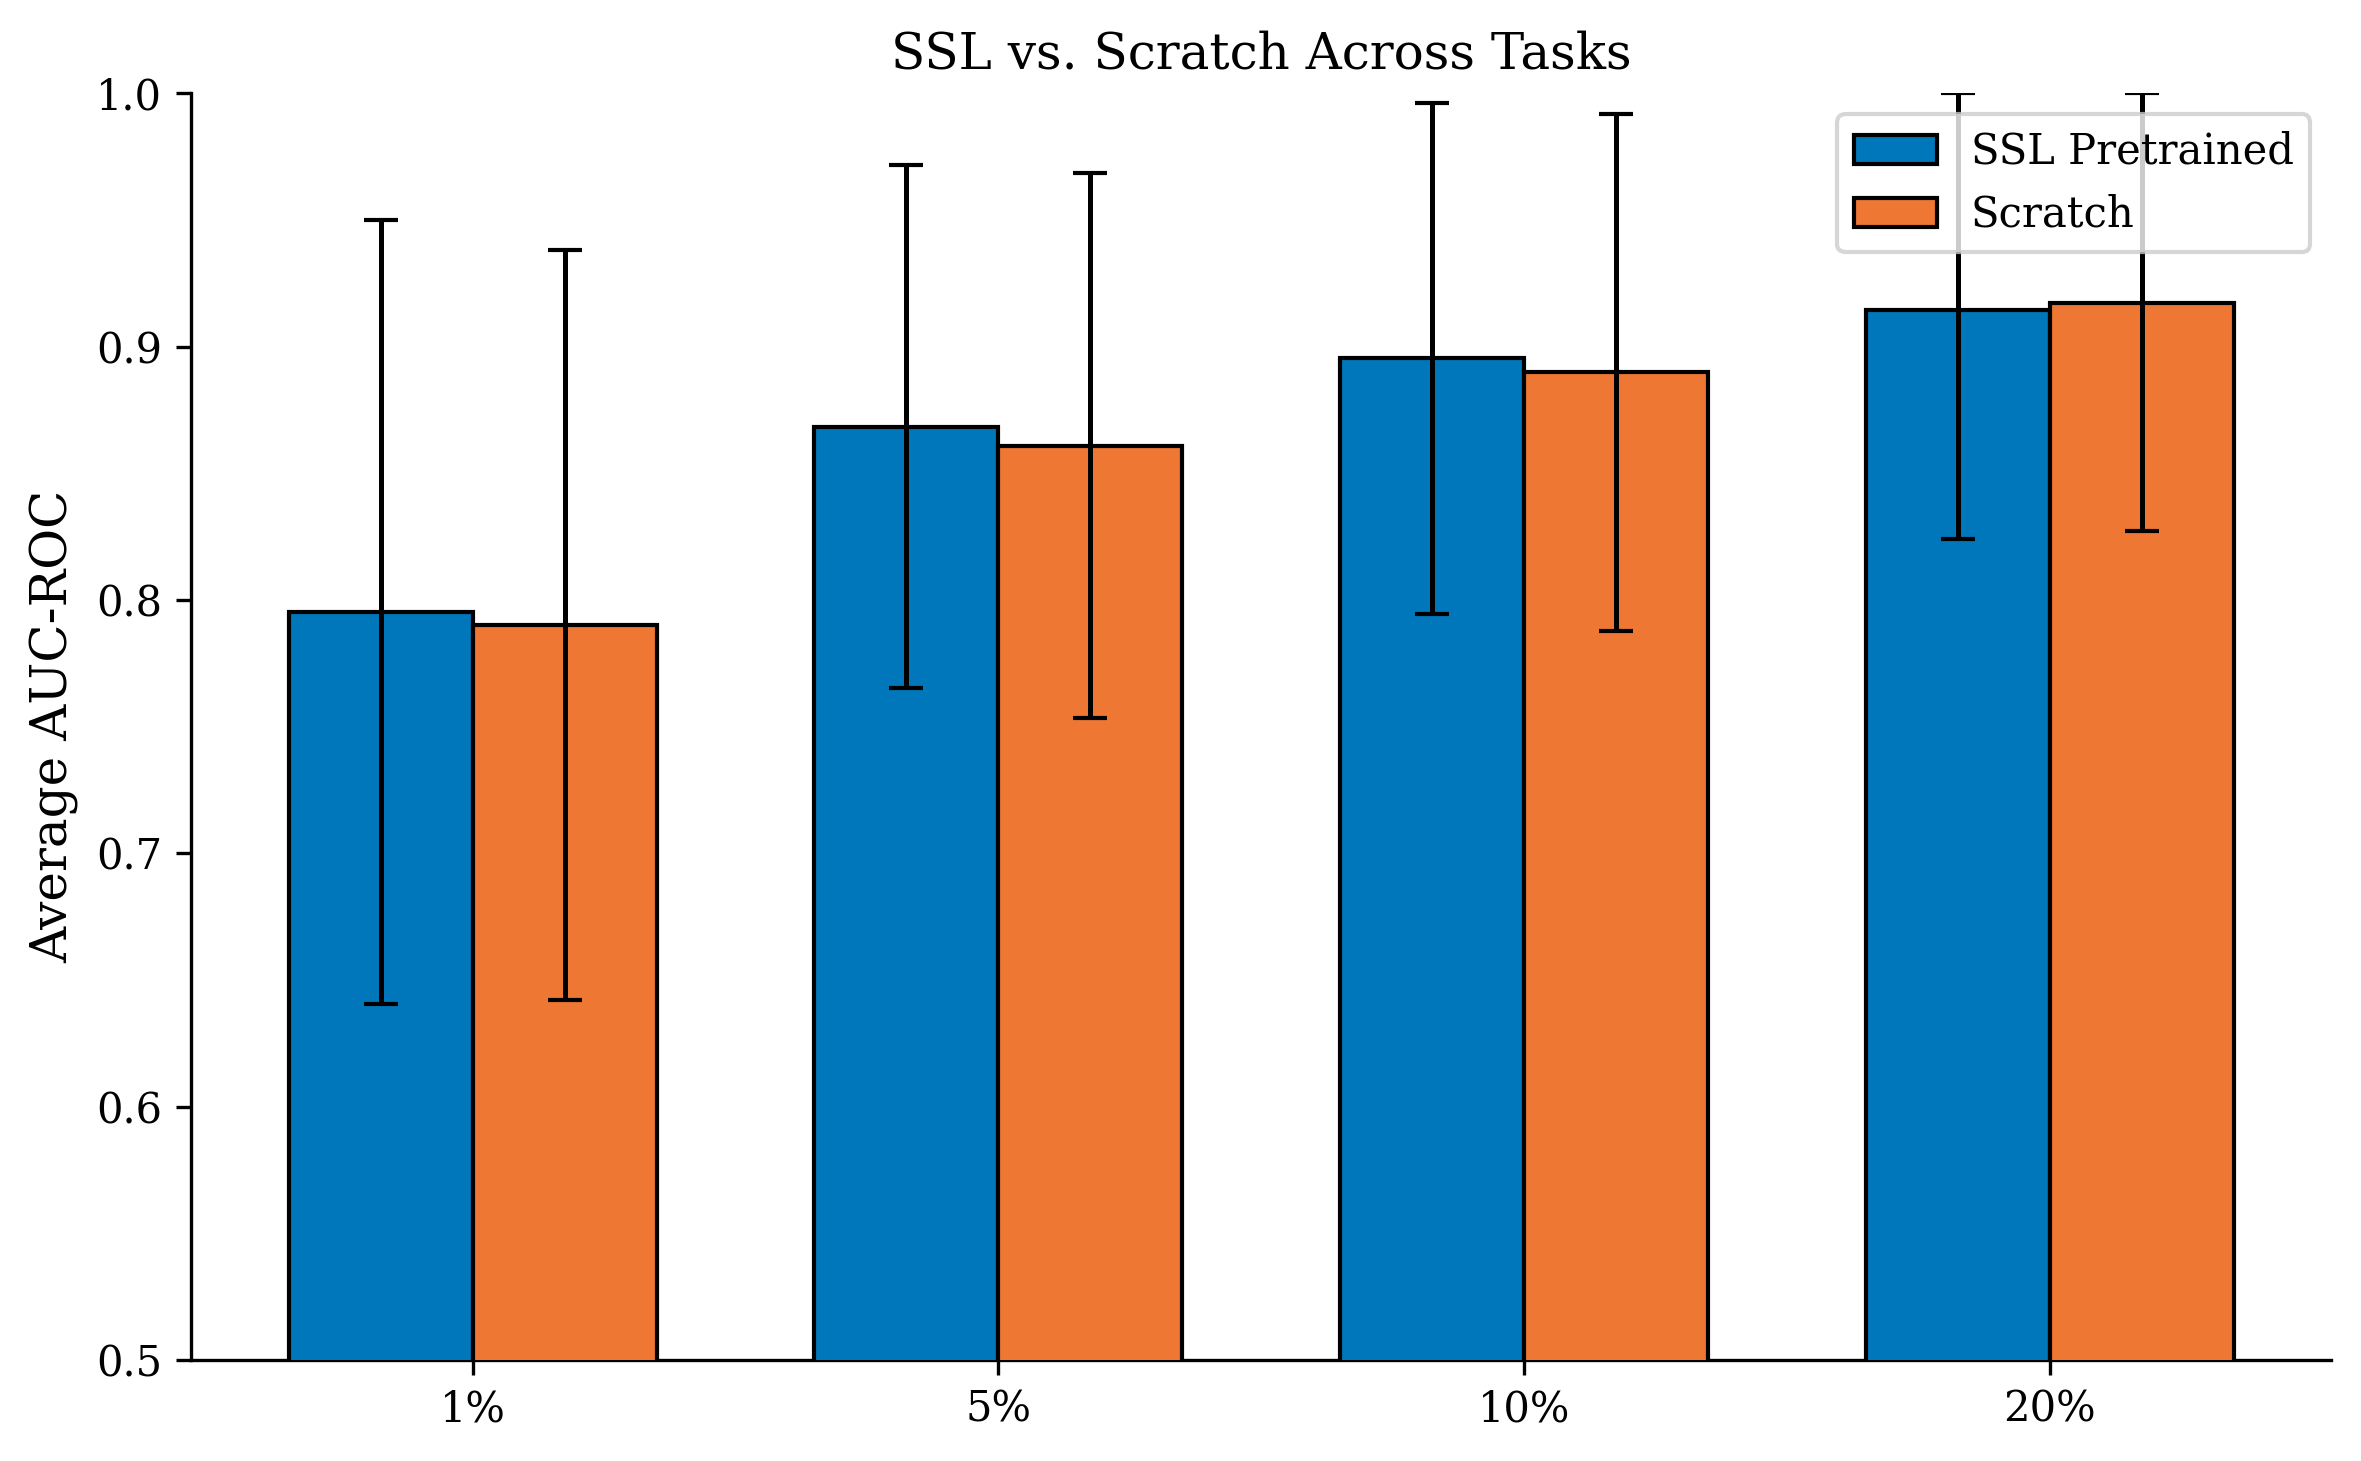

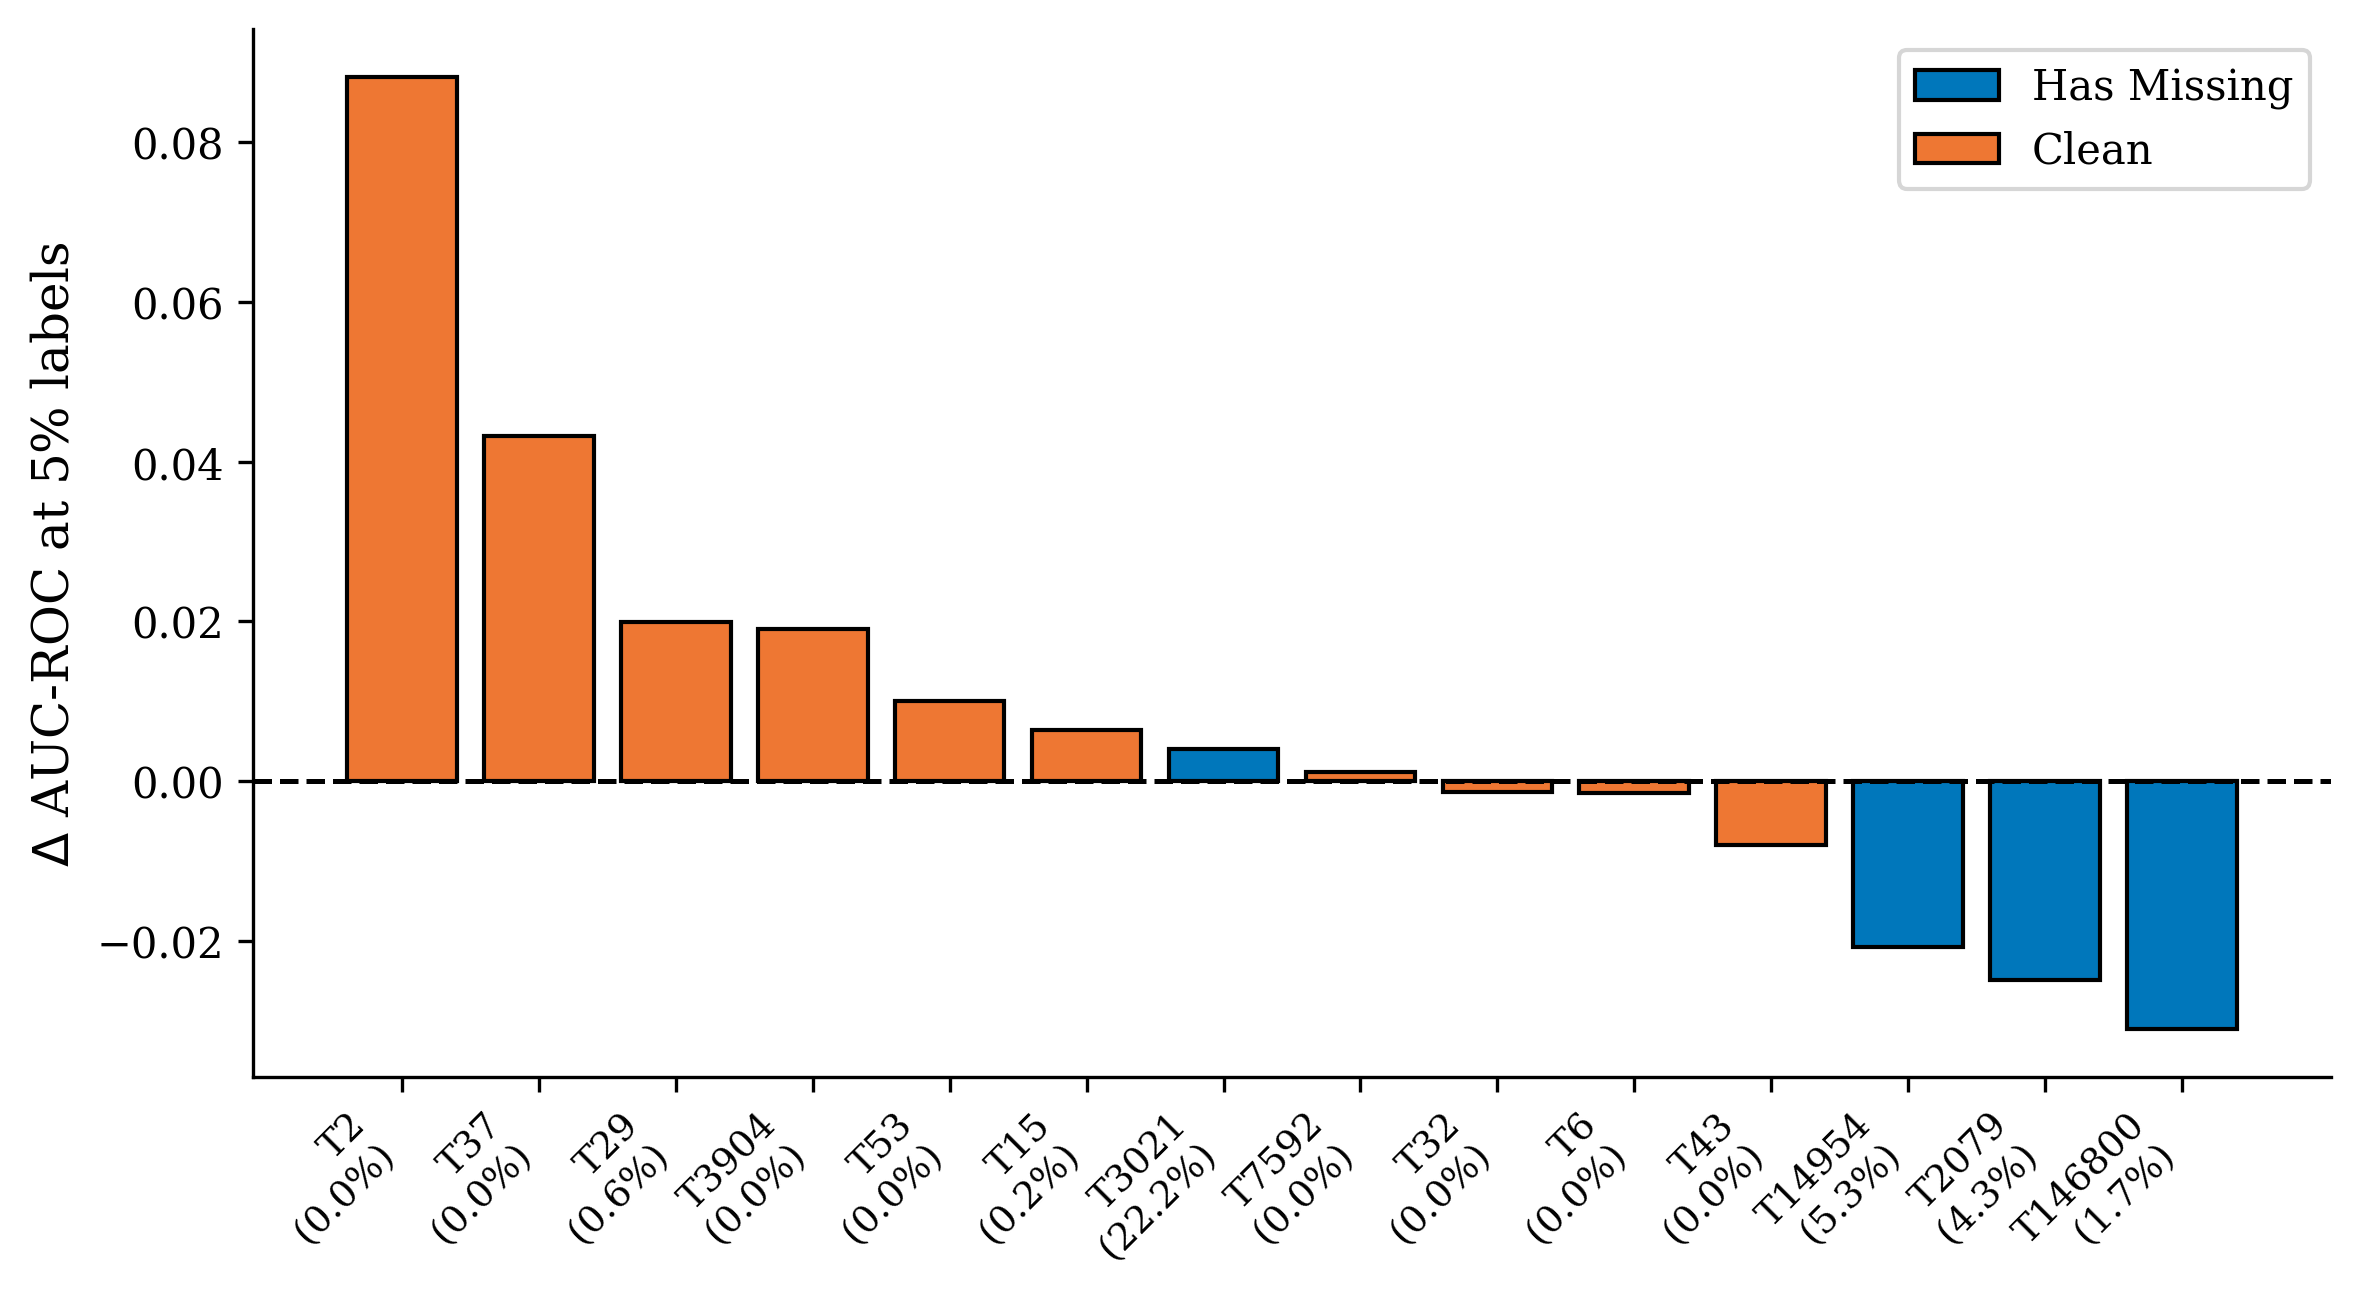

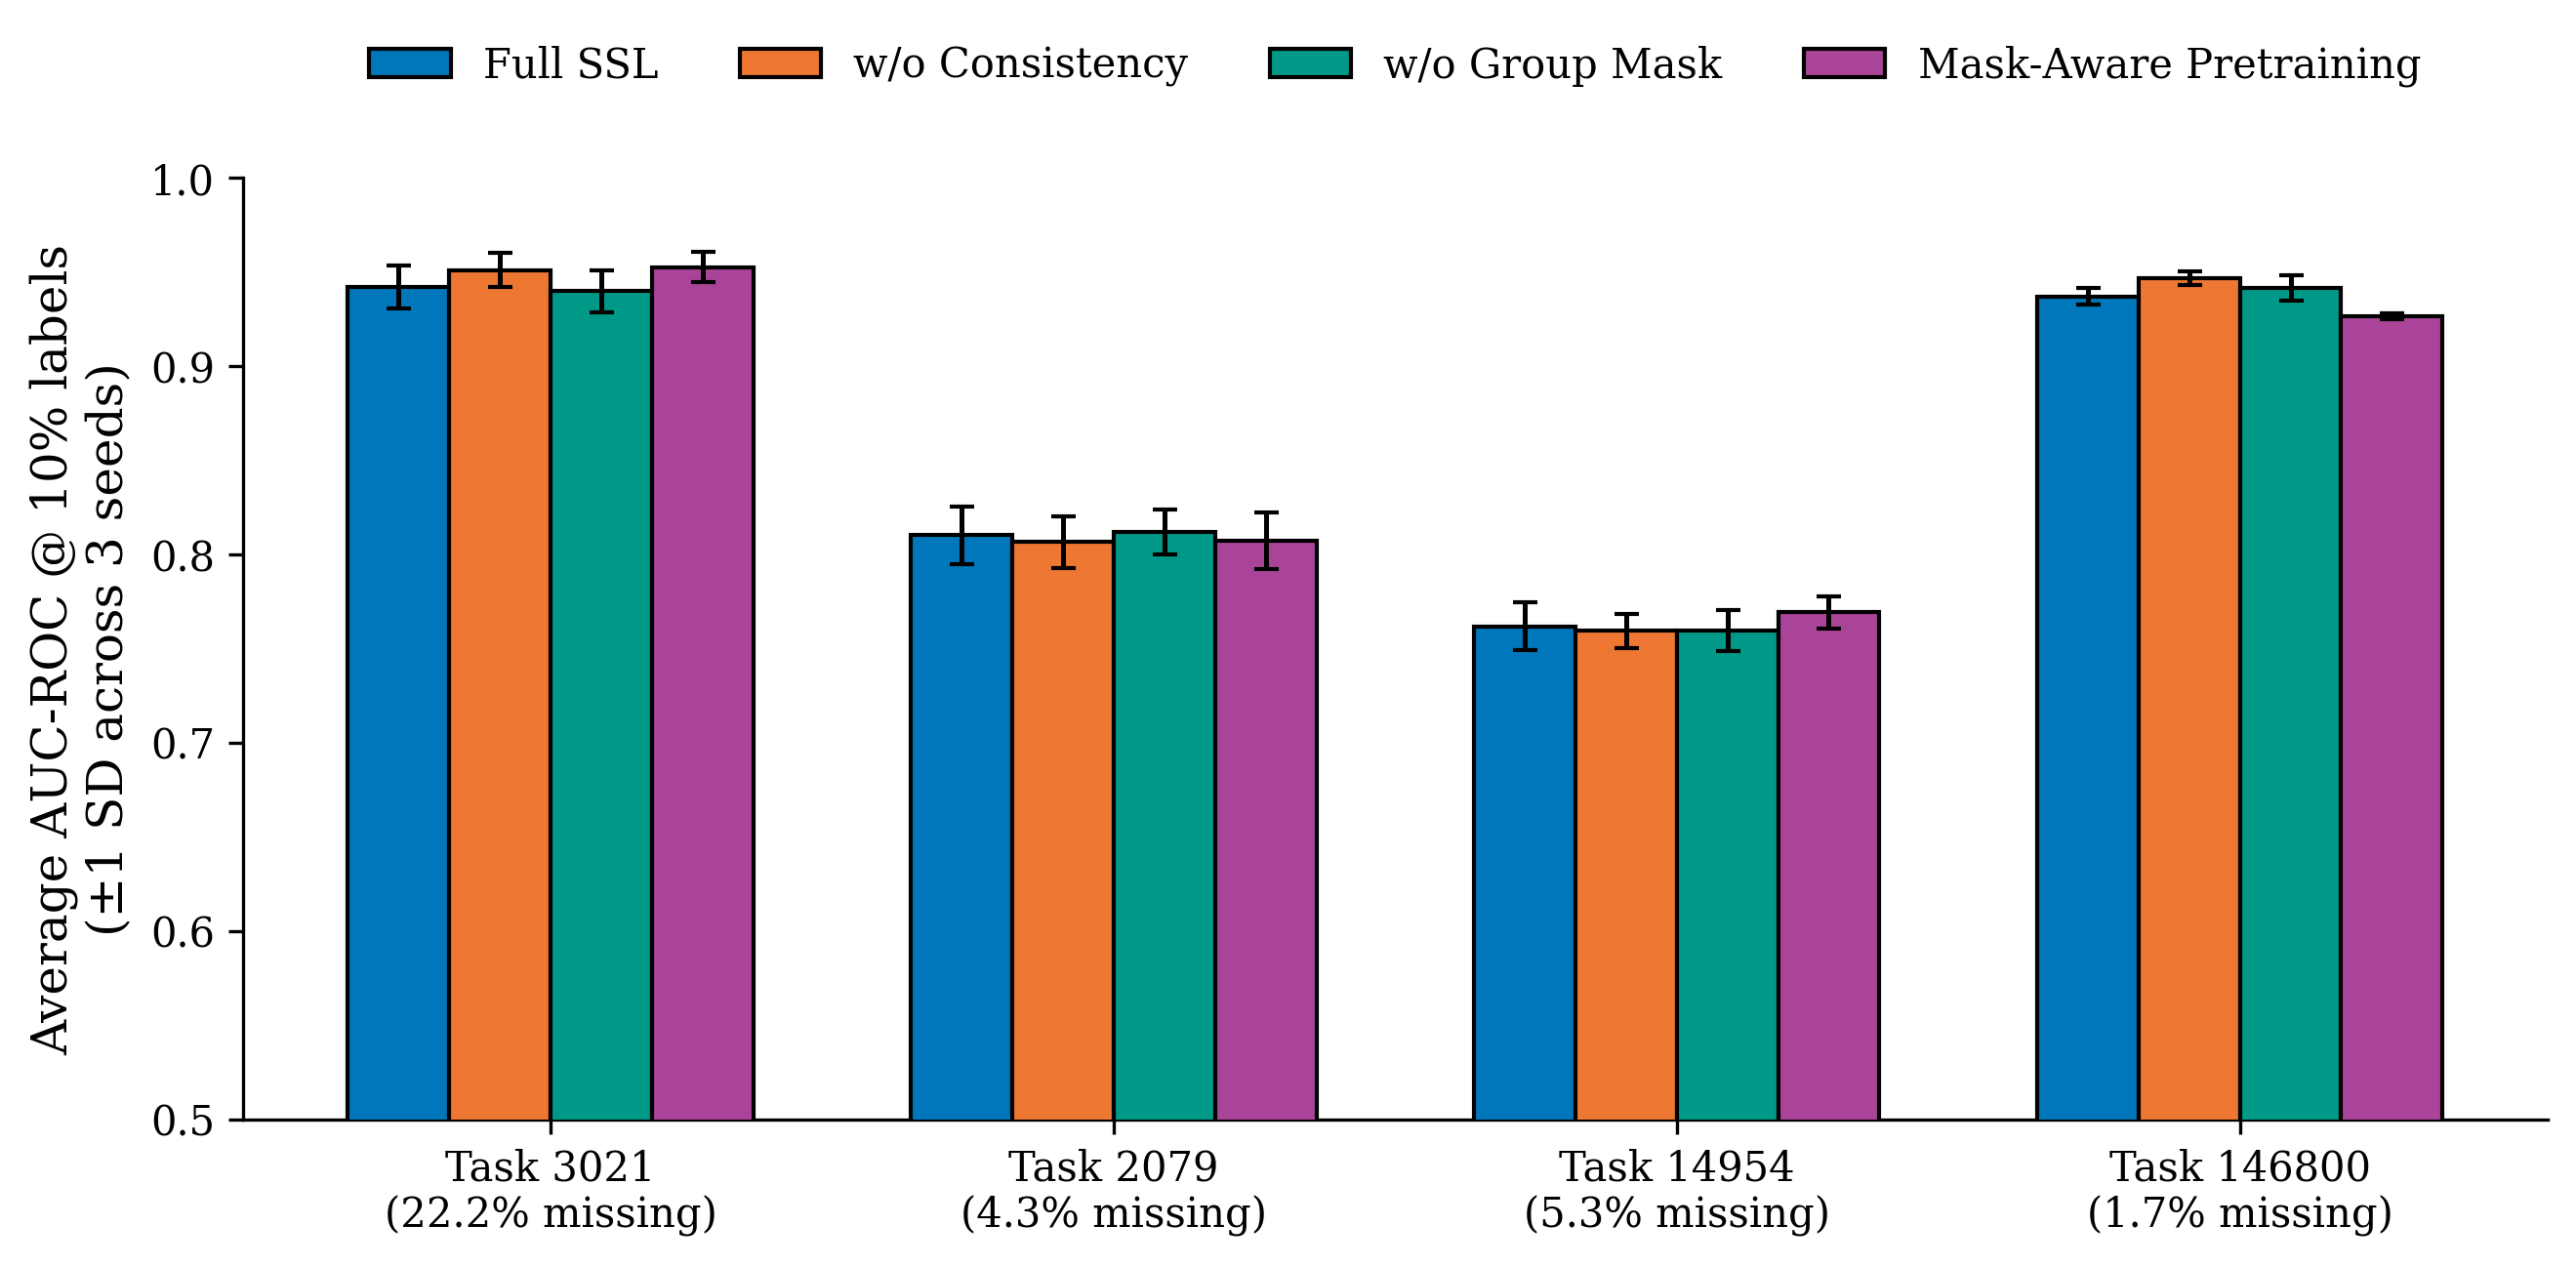

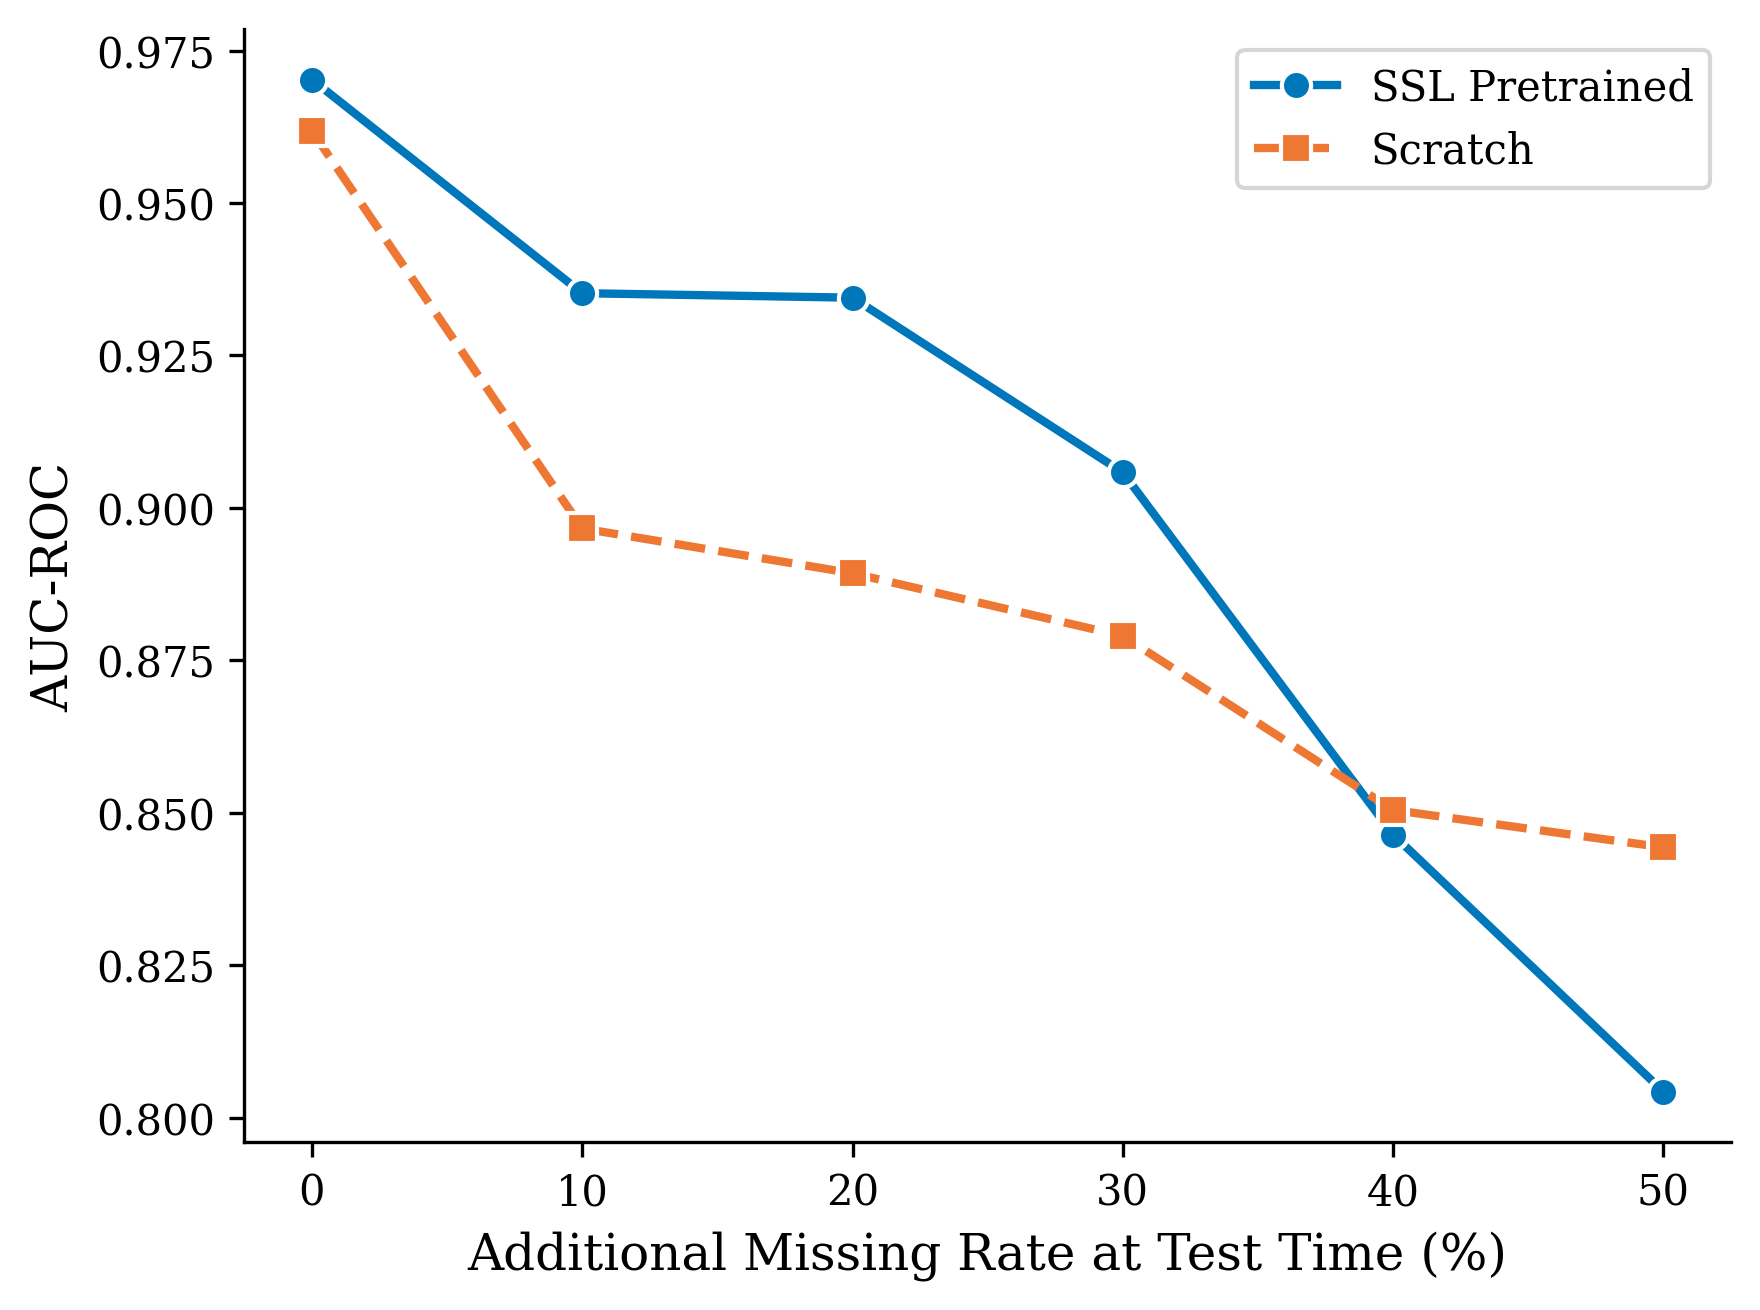

In [ ]:
# Builds the 4 paper figures and prints the label-scarcity Wilcoxon stats
# (5% and 10%), using the correct pretrained/scratch pipeline.
# MCAR/MNAR robustness stats are loaded from results/robustness_fixed.json
# and computed in the final cell, not here.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import wilcoxon


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False
})


with open(f'{PROJECT}/results/heavy_compute_results.json', 'r') as f:
    loaded_data = json.load(f)


baseline_results = loaded_data['baseline_results']

ablation_results = {int(k): v for k, v in loaded_data['ablation_results'].items()}
ablation_raw = {int(k): v for k, v in loaded_data['ablation_raw'].items()}


rates = loaded_data['robustness_curve']['rates']
curve_ssl = loaded_data['robustness_curve']['curve_ssl']
curve_scr = loaded_data['robustness_curve']['curve_scr']

rows = []

for tid, res in all_results.items():
    row = {'task': tid, 'missing%': res['missing_pct']}

    for frac in [0.01, 0.05, 0.10, 0.20]:
        k = str(frac)

        row[f'SSL_{int(frac*100)}%'] = np.mean(res['pretrained'][k])
        row[f'Scr_{int(frac*100)}%'] = np.mean(res['scratch'][k])
        row[f'Δ_{int(frac*100)}%'] = row[f'SSL_{int(frac*100)}%'] - row[f'Scr_{int(frac*100)}%']

    rows.append(row)


df = pd.DataFrame(rows)

print("Statistical significance (label scarcity, raw p-values)")

stat_5, p_5 = wilcoxon(df['SSL_5%'], df['Scr_5%'])
mean_5 = (df['SSL_5%'] - df['Scr_5%']).mean()
print(f"Label Scarcity (5%): Mean Delta = {mean_5:+.4f} | p-value = {p_5:.4f}")

stat_10, p_10 = wilcoxon(df['SSL_10%'], df['Scr_10%'])
mean_10 = (df['SSL_10%'] - df['Scr_10%']).mean()
print(f"Label Scarcity (10%): Mean Delta = {mean_10:+.4f} | p-value = {p_10:.4f}")
print()

fracs, labels = [0.01, 0.05, 0.10, 0.20], ['1%', '5%', '10%', '20%']

ssl_means = [df[f'SSL_{int(f*100)}%'].mean() for f in fracs]

scr_means = [df[f'Scr_{int(f*100)}%'].mean() for f in fracs]
ssl_stds = [df[f'SSL_{int(f*100)}%'].std() for f in fracs]
scr_stds = [df[f'Scr_{int(f*100)}%'].std() for f in fracs]


ssl_yerr = [ssl_stds, [min(std, 1.0 - mean) for mean, std in zip(ssl_means, ssl_stds)]]
scr_yerr = [scr_stds, [min(std, 1.0 - mean) for mean, std in zip(scr_means, scr_stds)]]

x, w = np.arange(len(fracs)), 0.35
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - w/2, ssl_means, w, yerr=ssl_yerr, label='SSL Pretrained', color='#0077BB', edgecolor='black', linewidth=1.0, capsize=4, error_kw={'elinewidth': 1.2, 'ecolor': 'black'}, zorder=3)

ax.bar(x + w/2, scr_means, w, yerr=scr_yerr, label='Scratch', color='#EE7733', edgecolor='black', linewidth=1.0, capsize=4, error_kw={'elinewidth': 1.2, 'ecolor': 'black'}, zorder=3)


ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Average AUC-ROC')
ax.set_title('SSL vs. Scratch Across Tasks')
ax.legend()

ax.set_ylim(0.5, 1.0)
fig.tight_layout()
plt.savefig(f'{PROJECT}/plots/main_comparison.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(8, 4.5))
df_sorted = df.sort_values(by='Δ_5%', ascending=False)

CLEAN_THRESHOLD = 1.0
colors = ['#0077BB' if m > CLEAN_THRESHOLD else '#EE7733' for m in df_sorted['missing%']]

ax.bar(range(len(df_sorted)), df_sorted['Δ_5%'], color=colors, edgecolor='black', linewidth=1.0, zorder=3)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, zorder=4)

ax.set_xticks(range(len(df_sorted)))

ax.set_xticklabels([f"T{t}\n({m:.1f}%)" for t, m in zip(df_sorted['task'], df_sorted['missing%'])], fontsize=9)
plt.xticks(rotation=45, ha='right')

ax.set_ylabel('$\Delta$ AUC-ROC at 5% labels')


ax.legend(handles=[Patch(facecolor='#0077BB', edgecolor='black', linewidth=1.0, label='Has Missing'),
                   Patch(facecolor='#EE7733', edgecolor='black', linewidth=1.0, label='Clean')])

fig.tight_layout()
plt.savefig(f'{PROJECT}/plots/missing_vs_clean.pdf', bbox_inches='tight')
plt.show()


ablation_tasks = list(ablation_results.keys())
missing_lookup = dict(zip(df['task'], df['missing%']))

x = np.arange(len(ablation_tasks))
w = 0.18
fig, ax = plt.subplots(figsize=(9, 4.5))

variant_names = ['full', 'no_consistency', 'no_group_mask', 'mask_aware']
variant_labels = ['Full SSL', 'w/o Consistency', 'w/o Group Mask', 'Mask-Aware Pretraining']

variant_colors = ['#0077BB', '#EE7733', '#009988', '#AA4499']
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]


for v_name, v_label, v_color, off in zip(variant_names, variant_labels, variant_colors, offsets):

    means = [ablation_results[t][v_name] for t in ablation_tasks]
    stds = [np.std(ablation_raw[t][v_name]) for t in ablation_tasks]

    yerr = [stds, [min(std, 1.0 - mean) for mean, std in zip(means, stds)]]

    ax.bar(x + off, means, w, yerr=yerr, capsize=3, error_kw={'elinewidth': 1.2, 'ecolor': 'black'},
       label=v_label, color=v_color, edgecolor='black', linewidth=1.0, zorder=3)


ax.set_xticks(x)
ax.set_xticklabels([f"Task {t}\n({missing_lookup.get(t, 0):.1f}% missing)" for t in ablation_tasks])

ax.set_ylabel('Average AUC-ROC @ 10% labels\n(±1 SD across 3 seeds)')

ax.legend(bbox_to_anchor=(0.5, 1.18), loc='upper center', ncol=4, frameon=False)
ax.set_ylim(0.5, 1.0)


fig.tight_layout()
plt.savefig(f'{PROJECT}/plots/ablation_comparison.pdf', bbox_inches='tight', pad_inches=0.15)

plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot([r*100 for r in rates], curve_ssl, marker='o', linestyle='-', linewidth=2, markersize=7,
        markeredgecolor='white', markeredgewidth=1.0, label='SSL Pretrained', color='#0077BB', zorder=3)



ax.plot([r*100 for r in rates], curve_scr, marker='s', linestyle='--', linewidth=2, markersize=7,
        markeredgecolor='white', markeredgewidth=1.0, label='Scratch', color='#EE7733', zorder=3)

ax.set_xlabel('Additional Missing Rate at Test Time (%)')
ax.set_ylabel('AUC-ROC')

ax.legend()

fig.tight_layout()

plt.savefig(f'{PROJECT}/plots/mcar_3021.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [ ]:
# Prints the label-scarcity table (paper Table 1), showing AUC per task
# across label fractions. The robustness table (Delta_MCAR/Delta_Shift)
# comes from the corrected pipeline in the final cell, not this one.
print(df[['task', 'missing%', 'SSL_1%', 'Scr_1%', 'SSL_5%', 'Scr_5%', 'SSL_10%', 'Scr_10%', 'SSL_20%', 'Scr_20%']].to_latex(index=False, float_format="%.3f"))


\begin{tabular}{rrrrrrrrrr}
\toprule
task & missing% & SSL_1% & Scr_1% & SSL_5% & Scr_5% & SSL_10% & Scr_10% & SSL_20% & Scr_20% \\
\midrule
2079 & 4.305 & 0.554 & 0.560 & 0.742 & 0.767 & 0.796 & 0.807 & 0.848 & 0.869 \\
3021 & 22.216 & 0.938 & 0.872 & 0.934 & 0.930 & 0.957 & 0.948 & 0.970 & 0.970 \\
14954 & 5.258 & 0.594 & 0.680 & 0.738 & 0.759 & 0.780 & 0.806 & 0.799 & 0.830 \\
146800 & 1.732 & 0.688 & 0.685 & 0.881 & 0.912 & 0.943 & 0.956 & 0.987 & 0.992 \\
2 & 0.000 & 0.700 & 0.594 & 0.864 & 0.776 & 0.976 & 0.923 & 0.991 & 0.982 \\
15 & 0.247 & 0.993 & 0.988 & 0.991 & 0.985 & 0.987 & 0.989 & 0.987 & 0.983 \\
29 & 0.617 & 0.843 & 0.858 & 0.866 & 0.846 & 0.866 & 0.842 & 0.885 & 0.887 \\
3904 & 0.010 & 0.662 & 0.640 & 0.643 & 0.624 & 0.650 & 0.633 & 0.690 & 0.672 \\
7592 & 0.000 & 0.873 & 0.858 & 0.882 & 0.881 & 0.885 & 0.886 & 0.893 & 0.895 \\
6 & 0.000 & 0.925 & 0.923 & 0.981 & 0.982 & 0.994 & 0.994 & 0.998 & 0.998 \\
32 & 0.000 & 0.989 & 0.987 & 0.997 & 0.999 & 1.000 & 1.000 & 1.00

In [ ]:
import os, pickle

def load_openml_task_cached(tid, cache_dir=f'{PROJECT}/cache/openml_tasks', **kwargs):
    os.makedirs(cache_dir, exist_ok=True)
    fpath = f'{cache_dir}/task_{tid}.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            return pickle.load(f)
    result = load_openml_task(tid, **kwargs)

    with open(fpath, 'wb') as f:
        pickle.dump(result, f)

    return result

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json
import os
from tqdm.auto import tqdm


class ProjectionHead(nn.Module):
    def __init__(self, in_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim)
        )

    def forward(self, h):
        z = self.net(h)
        return F.normalize(z, dim=-1)



def nt_xent_loss(z1, z2, temperature=0.5):
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temperature
    sim.fill_diagonal_(-1e9)
    targets = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, targets)



def permute_corrupt(x_num, m_num, x_cat, m_cat, corrupt_rate=0.3):
    B = x_num.shape[0]
    corrupt_mask_num = (torch.rand_like(x_num) < corrupt_rate).float()

    corrupt_mask_cat = (torch.rand_like(x_cat.float()) < corrupt_rate).float() if x_cat.shape[1] > 0 else x_cat.float()


    x_num_c = x_num.clone()


    for j in range(x_num.shape[1]):
        perm = torch.randperm(B, device=x_num.device)
        col_mask = corrupt_mask_num[:, j].bool()
        x_num_c[col_mask, j] = x_num[perm, j][col_mask]


    x_cat_c = x_cat.clone()

    for j in range(x_cat.shape[1]):
        perm = torch.randperm(B, device=x_cat.device)
        col_mask = corrupt_mask_cat[:, j].bool()
        x_cat_c[col_mask, j] = x_cat[perm, j][col_mask]

    return x_num_c, x_cat_c, corrupt_mask_num, corrupt_mask_cat


def single_view_recon_loss(n_preds, c_logits, xn, xc, smn, smc):
    rec, n_terms = torch.tensor(0.0, device=xn.device), 0


    if n_preds is not None and smn.sum() > 0:
        rec += (((n_preds - xn) ** 2) * smn).sum() / (smn.sum() + 1e-8)
        n_terms += 1


    if c_logits and smc.sum() > 0:
        cat_rec, n_ct = torch.tensor(0.0, device=xn.device), 0

        for j, logits_j in enumerate(c_logits):
            mask_j = smc[:, j].bool()
            if mask_j.sum() > 0:
                ce = F.cross_entropy(logits_j[mask_j], xc[:, j][mask_j])
                if not torch.isnan(ce):
                    cat_rec += ce
                    n_ct += 1


        if n_ct > 0:
            rec += cat_rec / n_ct
            n_terms += 1
    return rec / max(n_terms, 1)




class VIMEHeads(nn.Module):
    def __init__(self, hidden_dim, n_num, cat_sizes):
        super().__init__()
        self.recon_heads = SSLDecoderHeads(hidden_dim, n_num, cat_sizes)

        total_feats = n_num + len(cat_sizes)

        self.mask_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, total_feats)
        )


def vime_loss(enc, heads, x_num, m_num, x_cat, m_cat, alpha=2.0):

    x_num_c, x_cat_c, cmask_num, cmask_cat = permute_corrupt(x_num, m_num, x_cat, m_cat, corrupt_rate=0.3)

    h = enc(x_num_c, m_num, x_cat_c, m_cat)

    n_preds, c_logits = heads.recon_heads(h)
    recon_loss = single_view_recon_loss(n_preds, c_logits, x_num, x_cat, cmask_num, cmask_cat)

    true_mask = torch.cat([cmask_num, cmask_cat], dim=1)
    pred_mask_logits = heads.mask_head(h)

    mask_loss = F.binary_cross_entropy_with_logits(pred_mask_logits, true_mask)

    return recon_loss + alpha * mask_loss


def pretrain_vime(enc, heads, tr_ds, device, n_epochs=50, batch_size=128):

    opt = torch.optim.AdamW(list(enc.parameters()) + list(heads.parameters()), lr=1e-3, weight_decay=1e-4)
    ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)

    enc.train(); heads.train()

    for _ in range(n_epochs):

        for b in ld:
            x_num, m_num = b['x_num'].to(device), b['m_num'].to(device)
            x_cat, m_cat = b['x_cat'].to(device), b['m_cat'].to(device)

            loss = vime_loss(enc, heads, x_num, m_num, x_cat, m_cat)
            opt.zero_grad(); loss.backward(); opt.step()


def scarf_loss(enc, proj, x_num, m_num, x_cat, m_cat, temperature=0.5):

    x_num_c, x_cat_c, _, _ = permute_corrupt(x_num, m_num, x_cat, m_cat, corrupt_rate=0.3)
    h1 = enc(x_num, m_num, x_cat, m_cat)

    h2 = enc(x_num_c, m_num, x_cat_c, m_cat)
    z1, z2 = proj(h1), proj(h2)

    return nt_xent_loss(z1, z2, temperature=temperature)


def pretrain_scarf(enc, proj, tr_ds, device, n_epochs=50, batch_size=128):

    opt = torch.optim.AdamW(list(enc.parameters()) + list(proj.parameters()), lr=1e-3, weight_decay=1e-4)
    ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    enc.train(); proj.train()


    for _ in range(n_epochs):
        for b in ld:
            x_num, m_num = b['x_num'].to(device), b['m_num'].to(device)
            x_cat, m_cat = b['x_cat'].to(device), b['m_cat'].to(device)
            loss = scarf_loss(enc, proj, x_num, m_num, x_cat, m_cat)
            opt.zero_grad(); loss.backward(); opt.step()


def make_feature_subsets(n_num, n_cat, k_subsets=3, overlap_ratio=0.75):

    total = n_num + n_cat
    subset_size = int(total * overlap_ratio / max(k_subsets - (k_subsets - 1) * (1 - overlap_ratio), 1))
    subset_size = max(subset_size, max(1, total // k_subsets))

    subsets = []
    all_idx = np.arange(total)

    for _ in range(k_subsets):
        subsets.append(np.random.choice(all_idx, size=min(subset_size, total), replace=False))
    return subsets



def apply_subset_mask(x_num, m_num, x_cat, m_cat, subset_idx, n_num):
    total = n_num + x_cat.shape[1]
    keep = np.zeros(total, dtype=bool)

    keep[subset_idx] = True
    keep_num = torch.tensor(keep[:n_num], device=x_num.device)
    keep_cat = torch.tensor(keep[n_num:], device=x_cat.device)

    x_num_s = x_num.clone(); m_num_s = m_num.clone()
    x_num_s[:, ~keep_num] = 0.0

    m_num_s[:, ~keep_num] = 1.0

    x_cat_s = x_cat.clone(); m_cat_s = m_cat.clone()

    if x_cat.shape[1] > 0:
        x_cat_s[:, ~keep_cat] = 0

        m_cat_s[:, ~keep_cat] = 1.0

    return x_num_s, m_num_s, x_cat_s, m_cat_s



def subtab_loss(enc, heads, proj, x_num, m_num, x_cat, m_cat, n_num, k_subsets=3, contrastive_weight=0.5):
    subsets = make_feature_subsets(n_num, x_cat.shape[1], k_subsets=k_subsets)
    hs, recon_losses = [], []


    for subset_idx in subsets:

        x_num_s, m_num_s, x_cat_s, m_cat_s = apply_subset_mask(x_num, m_num, x_cat, m_cat, subset_idx, n_num)
        h_s = enc(x_num_s, m_num_s, x_cat_s, m_cat_s)
        hs.append(h_s)

        full_mask_num = torch.ones_like(m_num)
        full_mask_cat = torch.ones_like(m_cat) if x_cat.shape[1] > 0 else m_cat

        n_preds, c_logits = heads(h_s)
        recon_losses.append(single_view_recon_loss(n_preds, c_logits, x_num, x_cat, full_mask_num, full_mask_cat))

    recon_loss = torch.stack(recon_losses).mean()

    zs = [proj(h) for h in hs]
    contrastive_loss = 0.0

    n_pairs = 0


    for i in range(len(zs)):

        for j in range(i + 1, len(zs)):

            contrastive_loss = contrastive_loss + nt_xent_loss(zs[i], zs[j])
            n_pairs += 1

    contrastive_loss = contrastive_loss / max(n_pairs, 1)

    return recon_loss + contrastive_weight * contrastive_loss





def pretrain_subtab(enc, heads, proj, tr_ds, n_num, device, n_epochs=50, batch_size=128, k_subsets=3):
    opt = torch.optim.AdamW(list(enc.parameters()) + list(heads.parameters()) + list(proj.parameters()),
                             lr=1e-3, weight_decay=1e-4)

    ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    enc.train(); heads.train(); proj.train()

    for _ in range(n_epochs):

        for b in ld:
            x_num, m_num = b['x_num'].to(device), b['m_num'].to(device)
            x_cat, m_cat = b['x_cat'].to(device), b['m_cat'].to(device)
            loss = subtab_loss(enc, heads, proj, x_num, m_num, x_cat, m_cat, n_num, k_subsets=k_subsets)
            opt.zero_grad(); loss.backward(); opt.step()


print("SSL baseline comparison: VIME / SCARF / SubTab (10% labels)")


results_file = f'{PROJECT}/results/ssl_baseline_results.json'

if os.path.exists(results_file):

    with open(results_file, 'r') as f:
        ssl_baseline_results = json.load(f)
    completed_tasks = len(ssl_baseline_results['VIME'])
    print(f"Resuming from task index {completed_tasks}")


else:
    ssl_baseline_results = {'VIME': [], 'SCARF': [], 'SubTab': []}
    completed_tasks = 0


SSL_BASELINE_SEEDS = [SEED, SEED + 1, SEED + 2]

pbar = tqdm(TASK_LIST, desc="Processing SSL Baselines")


for i, tid in enumerate(pbar):

    if i < completed_tasks:
        pbar.write(f"  Task {tid} already processed, skipping...")
        continue

    pbar.set_postfix({'Task': tid})

    X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task_cached(tid, verbose=False)
    set_seed(SEED)
    p = TabularPreprocessor(cat_ind)
    Xn_tr, Mn_tr, Xc_tr, Mc_tr = p.fit_transform(X_tr)
    Xn_te, Mn_te, Xc_te, Mc_te = p.transform(X_te)

    tr_ds = TabularDataset(Xn_tr, Mn_tr, Xc_tr, Mc_tr, y_tr)
    te_ds = TabularDataset(Xn_te, Mn_te, Xc_te, Mc_te, y_te)
    ep = dict(n_num=Xn_tr.shape[1], cat_sizes=p.cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128)

    task_results = {'VIME': [], 'SCARF': [], 'SubTab': []}



    for p_seed in SSL_BASELINE_SEEDS:
        pbar.write(f"\n  Task {tid}: starting pretraining seed {p_seed} of {SSL_BASELINE_SEEDS[-1]}")

        pbar.write(f"    Training VIME")
        set_seed(p_seed)
        enc = TabularEncoder(**ep).to(device)
        heads = VIMEHeads(128, Xn_tr.shape[1], p.cat_sizes).to(device)
        pretrain_vime(enc, heads, tr_ds, device=device)

        torch.save({'encoder_state': enc.state_dict()}, 'tmp_vime.pt')
        res = finetune_and_evaluate('pretrained', 'tmp_vime.pt', tr_ds, te_ds, y_tr, n_cls, ep,
                                     label_fractions=[0.10], n_seeds=3, device=device)
        task_results['VIME'].append(np.mean(res[0.10]))


        pbar.write(f"    Training SCARF")
        set_seed(p_seed)
        enc = TabularEncoder(**ep).to(device)
        proj = ProjectionHead(128).to(device)

        pretrain_scarf(enc, proj, tr_ds, device=device)
        torch.save({'encoder_state': enc.state_dict()}, 'tmp_scarf.pt')
        res = finetune_and_evaluate('pretrained', 'tmp_scarf.pt', tr_ds, te_ds, y_tr, n_cls, ep,
                                     label_fractions=[0.10], n_seeds=3, device=device)

        task_results['SCARF'].append(np.mean(res[0.10]))



        pbar.write(f"    Training SubTab")
        set_seed(p_seed)
        enc = TabularEncoder(**ep).to(device)
        heads = SSLDecoderHeads(128, Xn_tr.shape[1], p.cat_sizes).to(device)
        proj = ProjectionHead(128).to(device)

        pretrain_subtab(enc, heads, proj, tr_ds, n_num=Xn_tr.shape[1], device=device)
        torch.save({'encoder_state': enc.state_dict()}, 'tmp_subtab.pt')
        res = finetune_and_evaluate('pretrained', 'tmp_subtab.pt', tr_ds, te_ds, y_tr, n_cls, ep,
                                     label_fractions=[0.10], n_seeds=3, device=device)
        task_results['SubTab'].append(np.mean(res[0.10]))


    for name in ['VIME', 'SCARF', 'SubTab']:

        task_mean = np.mean(task_results[name])
        ssl_baseline_results[name].append(task_mean)
        pbar.write(f"  Task {tid} | {name}: {task_mean:.4f} (std {np.std(task_results[name]):.4f})")

    with open(results_file, 'w') as f:
        json.dump(ssl_baseline_results, f, indent=4)
    pbar.write(f"  Task {tid}: results written to disk")



print("\nSSL Baseline Average AUC at 10% labels (across all 14 tasks):")

for name, aucs in ssl_baseline_results.items():
    print(f"  {name}: {np.mean(aucs):.4f}")

SSL baseline comparison: VIME / SCARF / SubTab (10% labels)
Resuming from task index 8

  Task 2079 already processed, skipping...
  Task 3021 already processed, skipping...
  Task 14954 already processed, skipping...
  Task 146800 already processed, skipping...
  Task 2 already processed, skipping...
  Task 15 already processed, skipping...
  Task 29 already processed, skipping...
  Task 3904 already processed, skipping...

  Task 7592: starting pretraining seed 42 of 44
    Training VIME
    Training SCARF
    Training SubTab

  Task 7592: starting pretraining seed 43 of 44
    Training VIME
    Training SCARF
    Training SubTab

  Task 7592: starting pretraining seed 44 of 44
    Training VIME
    Training SCARF
    Training SubTab
  Task 7592 | VIME: 0.8867 (std 0.0012)
  Task 7592 | SCARF: 0.8876 (std 0.0016)
  Task 7592 | SubTab: 0.8849 (std 0.0018)
  Task 7592: results written to disk

  Task 6: starting pretraining seed 42 of 44
    Training VIME
    Training SCARF
    Trainin

In [ ]:
import os
import json
import numpy as np
from scipy.stats import wilcoxon

print("Verification: Ours vs SSL baselines (10% labels)")

baseline_file = f"{PROJECT}/results/ssl_baseline_results.json"

raw_baselines = {}


if os.path.exists(baseline_file):
    with open(baseline_file, 'r') as f:
        raw_baselines = json.load(f)

else:
    print(f"ERROR: Cannot find baseline file at:\n{baseline_file}")


tasks = []
auc_ours, auc_vime, auc_scarf, auc_subtab = [], [], [], []


print(f"\n{'Task ID':<10} | {'Ours':<8} | {'VIME':<8} | {'SCARF':<8} | {'SubTab':<8}")
print("-" * 55)


for idx, tid in enumerate(TASK_LIST):

    t_str = str(tid)
    res_path = f"{PROJECT}/results/task_{tid}/results.json"


    if not os.path.exists(res_path):
        print(f"Skipping {t_str}: Cannot find {res_path}")
        continue


    with open(res_path, 'r') as f:
        data = json.load(f)
        ours_mean_auc = np.mean(data['pretrained']['0.1'])

    v_val, s_val, st_val = np.nan, np.nan, np.nan


    try:

        if isinstance(raw_baselines, list):

            for row in raw_baselines:
                if tid in row.values() or t_str in [str(v) for v in row.values()]:

                    v_val, s_val, st_val = row.get('VIME', np.nan), row.get('SCARF', np.nan), row.get('SubTab', np.nan)
                    break

        elif isinstance(raw_baselines, dict):

            if 'VIME' in raw_baselines and isinstance(raw_baselines['VIME'], list):
                v_val = raw_baselines['VIME'][idx] if idx < len(raw_baselines['VIME']) else np.nan

                s_val = raw_baselines.get('SCARF', [])[idx] if idx < len(raw_baselines.get('SCARF', [])) else np.nan

                st_val = raw_baselines.get('SubTab', [])[idx] if idx < len(raw_baselines.get('SubTab', [])) else np.nan

            elif t_str in raw_baselines:
                v_val = raw_baselines[t_str].get('VIME', np.nan)
                s_val = raw_baselines[t_str].get('SCARF', np.nan)

                st_val = raw_baselines[t_str].get('SubTab', np.nan)

            else:
                v_val = raw_baselines.get('VIME', {}).get(t_str, np.nan) if isinstance(raw_baselines.get('VIME'), dict) else np.nan
                s_val = raw_baselines.get('SCARF', {}).get(t_str, np.nan) if isinstance(raw_baselines.get('SCARF'), dict) else np.nan

                st_val = raw_baselines.get('SubTab', {}).get(t_str, np.nan) if isinstance(raw_baselines.get('SubTab'), dict) else np.nan

    except Exception:
        pass


    if np.isnan(v_val):
        print(f"Skipping {t_str}: Baseline data missing in JSON.")
        continue


    tasks.append(t_str)
    auc_ours.append(ours_mean_auc)
    auc_vime.append(v_val)

    auc_scarf.append(s_val)

    auc_subtab.append(st_val)

    print(f"{t_str:<10} | {ours_mean_auc:.4f}   | {v_val:.4f}   | {s_val:.4f}   | {st_val:.4f}")



if len(tasks) > 0:

    print("-" * 55)

    print(f"{'AVERAGE':<10} | {np.mean(auc_ours):.4f}   | {np.mean(auc_vime):.4f}   | {np.mean(auc_scarf):.4f}   | {np.mean(auc_subtab):.4f}\n")

    stat_v, p_vime = wilcoxon(auc_ours, auc_vime)
    stat_s, p_scarf = wilcoxon(auc_ours, auc_scarf)

    stat_st, p_subtab = wilcoxon(auc_ours, auc_subtab)


    print("\nStatistical significance: Wilcoxon signed-rank test")
    print(f"Ours vs VIME   : raw p-value = {p_vime:.4f}")

    print(f"Ours vs SCARF  : raw p-value = {p_scarf:.4f}")

    print(f"Ours vs SubTab : raw p-value = {p_subtab:.4f}\n")

    p_values = [('VIME', p_vime), ('SCARF', p_scarf), ('SubTab', p_subtab)]
    p_values.sort(key=lambda x: x[1])


    print("\nMultiple comparisons: Holm-Bonferroni adjustment")

    m = len(p_values)
    adjusted_p = {}
    prev_adj_p = 0.0




    for i, (name, p_val) in enumerate(p_values):
        adj_p = min(1.0, max(prev_adj_p, p_val * (m - i)))

        adjusted_p[name] = adj_p
        prev_adj_p = adj_p


    for name in ['VIME', 'SCARF', 'SubTab']:
        raw_p = eval(f'p_{name.lower()}')
        print(f"Ours vs {name:<6}: Raw p = {raw_p:.3f} | Holm-adjusted p = {adjusted_p[name]:.3f}")


else:

    print("\nNo data loaded")

Verification: Ours vs SSL baselines (10% labels)

Task ID    | Ours     | VIME     | SCARF    | SubTab  
-------------------------------------------------------
2079       | 0.7958   | 0.8109   | 0.8056   | 0.8023
3021       | 0.9571   | 0.9548   | 0.9498   | 0.9627
14954      | 0.7798   | 0.7803   | 0.7692   | 0.7689
146800     | 0.9429   | 0.9452   | 0.9320   | 0.9112
2          | 0.9763   | 0.9833   | 0.9752   | 0.9802
15         | 0.9873   | 0.9933   | 0.9919   | 0.9910
29         | 0.8655   | 0.8563   | 0.8579   | 0.8504
3904       | 0.6498   | 0.6681   | 0.6623   | 0.6558
7592       | 0.8851   | 0.8867   | 0.8876   | 0.8849
6          | 0.9938   | 0.9944   | 0.9931   | 0.9917
32         | 0.9998   | 0.9998   | 0.9999   | 0.9998
37         | 0.8402   | 0.8258   | 0.8325   | 0.8321
43         | 0.9432   | 0.9503   | 0.9516   | 0.9577
53         | 0.9191   | 0.9199   | 0.9118   | 0.8898
-------------------------------------------------------
AVERAGE    | 0.8954   | 0.8978   | 0.8943

In [ ]:
import numpy as np
scratch_10_seeds = [
    0.8569424964936887,
    0.820476858345021,
    0.7419354838709677
]



exact_mean = np.mean(scratch_10_seeds)

rounded_mean = round(exact_mean, 3)

print("Task 14954: scratch 10% sanity check")

print(f"Exact Mean (full float): {exact_mean}")
print(f"Rounded to 3 decimals:   {rounded_mean:.3f}")

Task 14954: scratch 10% sanity check
Exact Mean (full float): 0.8064516129032259
Rounded to 3 decimals:   0.806

In [ ]:
def load_openml_task_cached(tid, cache_dir=f'{PROJECT}/cache/openml_tasks', **kwargs):

    os.makedirs(cache_dir, exist_ok=True)
    fpath = f'{cache_dir}/task_{tid}.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            return pickle.load(f)

    result = load_openml_task(tid, **kwargs)

    with open(fpath, 'wb') as f:
        pickle.dump(result, f)
    return result

In [ ]:
import os, json
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
import os, pickle
def build_eval_model_fixed(ep, ppath, tr_ds, y_tr, n_cls, init_type, device):
    set_seed(SEED)
    e_ = TabularEncoder(**ep).to(device)
    if init_type == 'pretrained':
        e_.load_state_dict(torch.load(ppath, map_location=device)['encoder_state'])
    h_ = ClassificationHead(128, n_cls).to(device)
    n_lab = max(int(len(y_tr) * 0.10), n_cls)
    idx, _ = next(StratifiedShuffleSplit(1, train_size=n_lab, random_state=SEED).split(np.zeros(len(y_tr)), y_tr))
    ld = DataLoader(torch.utils.data.Subset(tr_ds, idx), batch_size=min(128, n_lab), shuffle=True)
    opt = torch.optim.AdamW(list(e_.parameters()) + list(h_.parameters()), lr=1e-3, weight_decay=1e-4)
    e_.train(); h_.train()
    for _ in range(30):
        for b in ld:
            loss = F.cross_entropy(
                h_(e_(b['x_num'].to(device), b['m_num'].to(device), b['x_cat'].to(device), b['m_cat'].to(device))),
                b['y'].to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    e_.eval(); h_.eval()
    return e_, h_

robustness_fixed = {}

for tid in TASK_LIST:
    ppath = f'{PROJECT}/results/task_{tid}/pretrained.pt'
    if not os.path.exists(ppath):
        print(f"  Task {tid}: no cached checkpoint found, skipping")
        continue

    X_tr, X_te, y_tr, y_te, cat_ind, n_cls = load_openml_task_cached(tid, verbose=False)
    p = TabularPreprocessor(cat_ind)
    Xn_tr, Mn_tr, Xc_tr, Mc_tr = p.fit_transform(X_tr)
    Xn_te, Mn_te, Xc_te, Mc_te = p.transform(X_te)
    tr_ds = TabularDataset(Xn_tr, Mn_tr, Xc_tr, Mc_tr, y_tr)
    ep = dict(n_num=Xn_tr.shape[1], cat_sizes=p.cat_sizes, embed_dim=32, hidden_dim=128, out_dim=128)

    e_p, h_p = build_eval_model_fixed(ep, ppath, tr_ds, y_tr, n_cls, 'pretrained', device)
    e_s, h_s = build_eval_model_fixed(ep, ppath, tr_ds, y_tr, n_cls, 'scratch', device)

    p_norm, p_mcar, p_shift = robustness_eval(e_p, h_p, Xn_te, Mn_te, Xc_te, Mc_te, y_te, n_cls, device)
    s_norm, s_mcar, s_shift = robustness_eval(e_s, h_s, Xn_te, Mn_te, Xc_te, Mc_te, y_te, n_cls, device)

    robustness_fixed[tid] = {
        'ssl': {'normal': p_norm, 'mcar': p_mcar, 'shift': p_shift},
        'scr': {'normal': s_norm, 'mcar': s_mcar, 'shift': s_shift}
    }
    print(f"  Task {tid}: done")

out_path = f'{PROJECT}/results/robustness_fixed.json'
with open(out_path, 'w') as f:
    json.dump(robustness_fixed, f, indent=2)
print(f"\nSaved corrected robustness numbers to: {out_path}")
print("Original results.json files were not modified.")

  Task 2079: done
  Task 3021: done
  Task 14954: done
  Task 146800: done
  Task 2: done
  Task 15: done
  Task 29: done
  Task 3904: done
  Task 7592: done
  Task 6: done
  Task 32: done
  Task 37: done
  Task 43: done
  Task 53: done

Saved corrected robustness numbers to: /content/drive/MyDrive/tabssl_project_new_4/results/robustness_fixed.json
Original results.json files were not modified.


In [ ]:
import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

with open(f'{PROJECT}/results/robustness_fixed.json') as f:
    robustness_fixed = {int(k): v for k, v in json.load(f).items()}

rows = []
for tid in TASK_LIST:
    with open(f'{PROJECT}/results/task_{tid}/results.json') as f:
        orig = json.load(f)
    row = {'task': tid}
    for frac in [0.05, 0.10]:
        k = str(frac)
        row[f'SSL_{int(frac*100)}%'] = np.mean(orig['pretrained'][k])
        row[f'Scr_{int(frac*100)}%'] = np.mean(orig['scratch'][k])
    row['Δ_MCAR_fixed'] = robustness_fixed[tid]['ssl']['mcar'] - robustness_fixed[tid]['scr']['mcar']
    row['Δ_Shift_fixed'] = robustness_fixed[tid]['ssl']['shift'] - robustness_fixed[tid]['scr']['shift']
    rows.append(row)

df = pd.DataFrame(rows)

stat5, p5 = wilcoxon(df['SSL_5%'], df['Scr_5%'])
stat10, p10 = wilcoxon(df['SSL_10%'], df['Scr_10%'])
stat_mcar, p_mcar = wilcoxon(df['Δ_MCAR_fixed'])
stat_shift, p_shift = wilcoxon(df['Δ_Shift_fixed'])

print("Corrected statistics (weight_decay=1e-4 for MCAR/MNAR fine-tuning):")
print(f"  5% labels:   Mean Delta = {(df['SSL_5%']-df['Scr_5%']).mean():+.4f} | p = {p5:.4f}")
print(f"  10% labels:  Mean Delta = {(df['SSL_10%']-df['Scr_10%']).mean():+.4f} | p = {p10:.4f}")
print(f"  MCAR +30%:   Mean Delta = {df['Δ_MCAR_fixed'].mean():+.4f} | p = {p_mcar:.4f}")
print(f"  MNAR shift:  Mean Delta = {df['Δ_Shift_fixed'].mean():+.4f} | p = {p_shift:.4f}")

_, p_adj, _, _ = multipletests([p5, p10, p_mcar, p_shift], alpha=0.05, method='holm')
print("\nHolm-adjusted (family of 4):")
for name, p in zip(['5%', '10%', 'MCAR', 'MNAR'], p_adj):
    print(f"  {name}: {p:.4f}")

Corrected statistics (weight_decay=1e-4 for MCAR/MNAR fine-tuning):
  5% labels:   Mean Delta = +0.0074 | p = 0.6257
  10% labels:  Mean Delta = +0.0055 | p = 0.6257
  MCAR +30%:   Mean Delta = +0.0245 | p = 0.0295
  MNAR shift:  Mean Delta = +0.0418 | p = 0.1726

Holm-adjusted (family of 4):
  5%: 1.0000
  10%: 1.0000
  MCAR: 0.1182
  MNAR: 0.5178


In [ ]:
import os, json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

PROJECT = '/content/drive/MyDrive/tabssl_project_new_4'
TASK_LIST = [2079, 3021, 14954, 146800, 2, 15, 29, 3904, 7592, 6, 32, 37, 43, 53]

with open(f'{PROJECT}/results/robustness_fixed.json') as f:
    robustness_fixed = {int(k): v for k, v in json.load(f).items()}

print("Results summary (corrected robustness numbers)")

rows = []
for tid in TASK_LIST:
    p = f'{PROJECT}/results/task_{tid}/results.json'
    if not os.path.exists(p):
        print(f"  Missing: {p}")
        continue
    with open(p) as f:
        res = json.load(f)

    row = {'task': tid}
    for frac in ['0.05', '0.1']:
        row[f'SSL_{frac}'] = np.mean(res['pretrained'][frac])
        row[f'Scr_{frac}'] = np.mean(res['scratch'][frac])

    rf = robustness_fixed[tid]
    row['Delta_MCAR'] = rf['ssl']['mcar'] - rf['scr']['mcar']
    row['Delta_Shift'] = rf['ssl']['shift'] - rf['scr']['shift']
    rows.append(row)

df = pd.DataFrame(rows)

print("\n1. Label-scarcity and robustness (Section 6.1 / 6.3)")

for frac, label in [('0.05', '5%'), ('0.1', '10%')]:
    ssl_avg = df[f'SSL_{frac}'].mean()
    scr_avg = df[f'Scr_{frac}'].mean()
    print(f"  {label} labels: SSL avg = {ssl_avg:.4f} | Scratch avg = {scr_avg:.4f} | Delta = {ssl_avg-scr_avg:+.4f}")

stat5, p5 = wilcoxon(df['SSL_0.05'], df['Scr_0.05'])
stat10, p10 = wilcoxon(df['SSL_0.1'], df['Scr_0.1'])
stat_mcar, p_mcar = wilcoxon(df['Delta_MCAR'])
stat_shift, p_shift = wilcoxon(df['Delta_Shift'])

print(f"\n  5% labels:  Mean Delta = {(df['SSL_0.05']-df['Scr_0.05']).mean():+.4f} | p = {p5:.4f}")
print(f"  10% labels: Mean Delta = {(df['SSL_0.1']-df['Scr_0.1']).mean():+.4f} | p = {p10:.4f}")
print(f"  MCAR +30%:  Mean Delta = {df['Delta_MCAR'].mean():+.4f} | p = {p_mcar:.4f}")
print(f"  MNAR shift: Mean Delta = {df['Delta_Shift'].mean():+.4f} | p = {p_shift:.4f}")

_, p_adj, _, _ = multipletests([p5, p10, p_mcar, p_shift], alpha=0.05, method='holm')
print("\n  Holm-adjusted (family of 4 primary tests):")
for name, p in zip(['5% labels', '10% labels', 'MCAR +30%', 'MNAR shift'], p_adj):
    print(f"    {name}: {p:.4f}")

pos_mcar = (df['Delta_MCAR'] > 0).sum()
pos_shift = (df['Delta_Shift'] > 0).sum()
print(f"\n  MCAR positive on {pos_mcar} of {len(df)} tasks")
print(f"  MNAR positive on {pos_shift} of {len(df)} tasks")

print("\n2. Appendix table (tab:robustness): per-task deltas")
print(df[['task', 'Delta_MCAR', 'Delta_Shift']].to_string(index=False, float_format='%.4f'))

Results summary (corrected robustness numbers)

1. Label-scarcity and robustness (Section 6.1 / 6.3)
  5% labels: SSL avg = 0.8684 | Scratch avg = 0.8610 | Delta = +0.0074
  10% labels: SSL avg = 0.8954 | Scratch avg = 0.8899 | Delta = +0.0055

  5% labels:  Mean Delta = +0.0074 | p = 0.6257
  10% labels: Mean Delta = +0.0055 | p = 0.6257
  MCAR +30%:  Mean Delta = +0.0245 | p = 0.0295
  MNAR shift: Mean Delta = +0.0418 | p = 0.1726

  Holm-adjusted (family of 4 primary tests):
    5% labels: 1.0000
    10% labels: 1.0000
    MCAR +30%: 0.1182
    MNAR shift: 0.5178

  MCAR positive on 11 of 14 tasks
  MNAR positive on 8 of 14 tasks

2. Appendix table (tab:robustness): per-task deltas
  task  Delta_MCAR  Delta_Shift
  2079     -0.0223      -0.0113
  3021      0.0267      -0.0185
 14954     -0.0000       0.0063
146800     -0.0203      -0.0466
     2      0.1551       0.1954
    15      0.0154      -0.0018
    29      0.0051       0.0068
  3904      0.0418       0.1661
  7592      0.0117

In [3]:
import os, json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests



PROJECT = '/content/drive/MyDrive/tabssl_project_new_4'
TASK_LIST = [2079, 3021, 14954, 146800, 2, 15, 29, 3904, 7592, 6, 32, 37, 43, 53]
ABLATION_TASKS = [3021, 2079, 14954, 146800]
ABLATION_VARIANTS = ['full', 'no_consistency', 'no_group_mask', 'mask_aware']

OUT_DIR = f'{PROJECT}/results/fixed_results'
os.makedirs(OUT_DIR, exist_ok=True)

def _load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

summary = {}

print("=" * 70)
print("LOADING CACHED RESULTS (no retraining)")
print("=" * 70)


task_results = {}
for tid in TASK_LIST:
    p = f'{PROJECT}/results/task_{tid}/results.json'
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing required file: {p}")
    task_results[tid] = _load_json(p)
print(f"Loaded results.json for {len(task_results)}/{len(TASK_LIST)} tasks.")


robustness_path = f'{PROJECT}/results/robustness_fixed.json'
robustness_fixed = {int(k): v for k, v in _load_json(robustness_path).items()}
print(f"Loaded corrected robustness numbers for {len(robustness_fixed)}/{len(TASK_LIST)} tasks.")


heavy = _load_json(f'{PROJECT}/results/heavy_compute_results.json')
baseline_results = heavy['baseline_results']
ablation_results = {int(k): v for k, v in heavy['ablation_results'].items()}
ablation_raw = {int(k): v for k, v in heavy['ablation_raw'].items()}
print("Loaded classical-baseline and ablation results.")


ssl_baseline_path = f'{PROJECT}/results/ssl_baseline_results.json'
ssl_baselines = _load_json(ssl_baseline_path)
print("Loaded VIME/SCARF/SubTab baseline results.")


print("\n" + "=" * 70)
print("1. LABEL SCARCITY (Section 6.1)")
print("=" * 70)

main_rows = []
for tid in TASK_LIST:
    res = task_results[tid]
    row = {'task': tid, 'missing_pct': res['missing_pct']}
    for frac in [0.01, 0.05, 0.10, 0.20]:
        k = str(frac)
        row[f'SSL_{int(frac*100)}'] = np.mean(res['pretrained'][k])
        row[f'Scr_{int(frac*100)}'] = np.mean(res['scratch'][k])
    main_rows.append(row)
main_df = pd.DataFrame(main_rows)

label_scarcity = {}
for frac in [1, 5, 10, 20]:
    ssl_avg = main_df[f'SSL_{frac}'].mean()
    scr_avg = main_df[f'Scr_{frac}'].mean()
    label_scarcity[f'{frac}pct'] = {
        'ssl_avg': ssl_avg, 'scr_avg': scr_avg, 'delta': ssl_avg - scr_avg
    }
    print(f"  {frac:>2}% labels: SSL = {ssl_avg:.4f} | Scratch = {scr_avg:.4f} | Delta = {ssl_avg - scr_avg:+.4f}")

stat5, p5 = wilcoxon(main_df['SSL_5'], main_df['Scr_5'])
stat10, p10 = wilcoxon(main_df['SSL_10'], main_df['Scr_10'])
print(f"\n  Wilcoxon p (5% labels)  = {p5:.4f}")
print(f"  Wilcoxon p (10% labels) = {p10:.4f}")
label_scarcity['wilcoxon_p_5pct'] = p5
label_scarcity['wilcoxon_p_10pct'] = p10
summary['label_scarcity'] = label_scarcity


print("\n" + "=" * 70)
print("2. MISSING VS. CLEAN PARADOX (Section 6.2)")
print("=" * 70)

main_df['delta_5'] = main_df['SSL_5'] - main_df['Scr_5']
clean_mask = main_df['missing_pct'] <= 1.0
missing_mean = main_df.loc[~clean_mask, 'delta_5'].mean()
clean_mean = main_df.loc[clean_mask, 'delta_5'].mean()
print(f"  Mean Delta_5% on 'Has Missing' tasks (>1% missing, n={(~clean_mask).sum()}): {missing_mean:+.4f}")
print(f"  Mean Delta_5% on 'Clean' tasks (<=1% missing, n={clean_mask.sum()}): {clean_mean:+.4f}")
summary['missing_vs_clean'] = {
    'mean_delta5_has_missing': missing_mean,
    'mean_delta5_clean': clean_mean
}


print("\n" + "=" * 70)
print("3. ROBUSTNESS TO TEST-TIME DEGRADATION (Section 6.3 / Table 6)")
print("=" * 70)

rob_rows = []
for tid in TASK_LIST:
    rf = robustness_fixed[tid]
    d_norm = rf['ssl']['normal'] - rf['scr']['normal']
    d_mcar = rf['ssl']['mcar'] - rf['scr']['mcar']
    d_shift = rf['ssl']['shift'] - rf['scr']['shift']
    rob_rows.append({
        'task': tid,
        'missing_pct': task_results[tid]['missing_pct'],
        'Delta_10': d_norm,
        'Delta_MCAR': d_mcar,
        'Delta_Shift': d_shift
    })
rob_df = pd.DataFrame(rob_rows)

stat_mcar, p_mcar = wilcoxon(rob_df['Delta_MCAR'])
stat_shift, p_shift = wilcoxon(rob_df['Delta_Shift'])

mean_mcar = rob_df['Delta_MCAR'].mean()
mean_shift = rob_df['Delta_Shift'].mean()
pos_mcar = int((rob_df['Delta_MCAR'] > 0).sum())
pos_shift = int((rob_df['Delta_Shift'] > 0).sum())

print(f"  MCAR +30%:  Mean Delta = {mean_mcar:+.4f} | raw p = {p_mcar:.4f} | positive on {pos_mcar}/{len(rob_df)} tasks")
print(f"  MNAR shift: Mean Delta = {mean_shift:+.4f} | raw p = {p_shift:.4f} | positive on {pos_shift}/{len(rob_df)} tasks")

family_names = ['5% labels', '10% labels', 'MCAR +30%', 'MNAR shift']
family_p = [p5, p10, p_mcar, p_shift]
_, p_adj, _, _ = multipletests(family_p, alpha=0.05, method='holm')

print("\n  Holm-Bonferroni correction (family of 4 primary tests):")
holm_family = {}
for name, praw, padj in zip(family_names, family_p, p_adj):
    print(f"    {name:<12} raw p = {praw:.4f} | Holm-adjusted p = {padj:.4f}")
    holm_family[name] = {'raw_p': praw, 'holm_adjusted_p': padj}

summary['robustness'] = {
    'mcar': {'mean_delta': mean_mcar, 'raw_p': p_mcar, 'positive_tasks': pos_mcar, 'n_tasks': len(rob_df)},
    'mnar_shift': {'mean_delta': mean_shift, 'raw_p': p_shift, 'positive_tasks': pos_shift, 'n_tasks': len(rob_df)},
    'holm_bonferroni_family_of_4': holm_family
}


print("\n" + "=" * 70)
print("4. CLASSICAL BASELINES @ 10% LABELS (Section 6.5 / Table 4)")
print("=" * 70)

classical_avgs = {name: float(np.mean(aucs)) for name, aucs in baseline_results.items()}
ssl_10_avg = main_df['SSL_10'].mean()
scr_10_avg = main_df['Scr_10'].mean()

print(f"  Random Forest        : {classical_avgs['RF']:.4f}")
print(f"  SSL Pretrained (Ours): {ssl_10_avg:.4f}")
print(f"  Scratch (No Pretrain): {scr_10_avg:.4f}")
print(f"  LightGBM              : {classical_avgs['LGBM']:.4f}")
print(f"  XGBoost                : {classical_avgs['XGB']:.4f}")
print(f"  Logistic Regression    : {classical_avgs['LR']:.4f}")
print(f"\n  SSL - LR   = {ssl_10_avg - classical_avgs['LR']:+.4f}")
print(f"  SSL - XGB  = {ssl_10_avg - classical_avgs['XGB']:+.4f}")
print(f"  SSL - LGBM = {ssl_10_avg - classical_avgs['LGBM']:+.4f}")
print(f"  RF - SSL   = {classical_avgs['RF'] - ssl_10_avg:+.4f}")

summary['classical_baselines_10pct'] = {
    'RF': classical_avgs['RF'], 'SSL_Pretrained': ssl_10_avg, 'Scratch': scr_10_avg,
    'LightGBM': classical_avgs['LGBM'], 'XGBoost': classical_avgs['XGB'],
    'LogisticRegression': classical_avgs['LR']
}


print("\n" + "=" * 70)
print("5. ABLATION STUDY (Section 6.4)")
print("=" * 70)

ablation_long_rows = []
for tid in ABLATION_TASKS:
    for v in ABLATION_VARIANTS:
        mean_v = ablation_results[tid][v]
        std_v = float(np.std(ablation_raw[tid][v]))
        ablation_long_rows.append({'task': tid, 'variant': v, 'mean_auc': mean_v, 'std_auc': std_v})
        print(f"  Task {tid:<6} | {v:<15} mean={mean_v:.4f}  std={std_v:.4f}")
ablation_long_df = pd.DataFrame(ablation_long_rows)

def ablation_deltas(variant):
    return [ablation_results[t][variant] - ablation_results[t]['full'] for t in ABLATION_TASKS]

ablation_summary = {}
print()
for variant, label in [('no_consistency', 'No Consistency Loss'),
                        ('no_group_mask', 'No Group Masking'),
                        ('mask_aware', 'Mask-Aware Pretraining')]:
    deltas = ablation_deltas(variant)
    stat, p = wilcoxon(deltas)
    mean_delta = float(np.mean(deltas))
    print(f"  {label}: per-task deltas (vs Full) = {[round(d,4) for d in deltas]}")
    print(f"    Mean Delta AUC = {mean_delta:+.4f} | Wilcoxon p (n=4) = {p:.4f}")
    ablation_summary[variant] = {
        'per_task_deltas': dict(zip(ABLATION_TASKS, [round(d, 4) for d in deltas])),
        'mean_delta': mean_delta, 'wilcoxon_p_n4': p
    }

full_seed_vals, noc_seed_vals = [], []
for t in ABLATION_TASKS:
    full_seed_vals += ablation_raw[t]['full']
    noc_seed_vals += ablation_raw[t]['no_consistency']
stat_seed, p_seed = wilcoxon(np.array(noc_seed_vals) - np.array(full_seed_vals))
print(f"\n  No-Consistency vs Full, 12 seed-level pairs: Wilcoxon p = {p_seed:.4f}")
ablation_summary['no_consistency_12_seed_pairs_p'] = p_seed

full_stds = [float(np.std(ablation_raw[t]['full'])) for t in ABLATION_TASKS]
print(f"  Full-variant per-task seed stds: {[round(s,4) for s in full_stds]}  "
      f"range: [{min(full_stds):.4f}, {max(full_stds):.4f}]")
ablation_summary['full_variant_seed_std_range'] = [min(full_stds), max(full_stds)]

summary['ablation'] = ablation_summary


print("\n" + "=" * 70)
print("6. VIME / SCARF / SUBTAB COMPARISON (Section 6.6 / Table 5)")
print("=" * 70)

auc_ours = [np.mean(task_results[tid]['pretrained']['0.1']) for tid in TASK_LIST]
auc_vime = ssl_baselines['VIME']
auc_scarf = ssl_baselines['SCARF']
auc_subtab = ssl_baselines['SubTab']

assert len(auc_vime) == len(TASK_LIST), "ssl_baseline_results.json length mismatch with TASK_LIST"

print(f"  Ours   avg = {np.mean(auc_ours):.4f}")
print(f"  VIME   avg = {np.mean(auc_vime):.4f}")
print(f"  SCARF  avg = {np.mean(auc_scarf):.4f}")
print(f"  SubTab avg = {np.mean(auc_subtab):.4f}")

stat_v, p_vime = wilcoxon(auc_ours, auc_vime)
stat_s, p_scarf = wilcoxon(auc_ours, auc_scarf)
stat_st, p_subtab = wilcoxon(auc_ours, auc_subtab)

raw_p = {'VIME': p_vime, 'SCARF': p_scarf, 'SubTab': p_subtab}
baseline_avgs_ssl = {'VIME': np.mean(auc_vime), 'SCARF': np.mean(auc_scarf), 'SubTab': np.mean(auc_subtab)}

print("\n  Raw Wilcoxon p-values:")
ssl_baseline_summary = {}
for name, p in raw_p.items():
    delta = np.mean(auc_ours) - baseline_avgs_ssl[name]
    print(f"    Ours vs {name:<6}: Delta = {delta:+.4f} | raw p = {p:.4f}")
    ssl_baseline_summary[name] = {'avg_auc': float(baseline_avgs_ssl[name]),
                                   'delta_vs_ours': float(delta), 'raw_p': float(p)}

names_sorted = sorted(raw_p, key=raw_p.get)
p_sorted = [raw_p[n] for n in names_sorted]
_, p_adj_sorted, _, _ = multipletests(p_sorted, alpha=0.05, method='holm')
adj_p = dict(zip(names_sorted, p_adj_sorted))

print("\n  Holm-Bonferroni adjusted (family of 3 tests):")
for name in ['VIME', 'SCARF', 'SubTab']:
    print(f"    Ours vs {name:<6}: Holm-adjusted p = {adj_p[name]:.4f}")
    ssl_baseline_summary[name]['holm_adjusted_p'] = float(adj_p[name])

summary['ssl_baseline_comparison'] = {
    'ours_avg_auc': float(np.mean(auc_ours)),
    **ssl_baseline_summary
}


print("\n" + "=" * 70)
print(f"SAVING RESULT FILES TO: {OUT_DIR}")
print("=" * 70)


main_df_out = main_df[['task', 'missing_pct', 'SSL_1', 'Scr_1', 'SSL_5', 'Scr_5',
                        'SSL_10', 'Scr_10', 'SSL_20', 'Scr_20']]
main_df_out.to_csv(f'{OUT_DIR}/table1_label_scarcity_per_task.csv', index=False)


rob_df.to_csv(f'{OUT_DIR}/table2_robustness_per_task.csv', index=False)


pd.DataFrame([
    {'method': 'Random Forest', 'avg_auc_10pct': classical_avgs['RF']},
    {'method': 'SSL Pretrained (Ours)', 'avg_auc_10pct': ssl_10_avg},
    {'method': 'Scratch (No Pretrain)', 'avg_auc_10pct': scr_10_avg},
    {'method': 'LightGBM', 'avg_auc_10pct': classical_avgs['LGBM']},
    {'method': 'XGBoost', 'avg_auc_10pct': classical_avgs['XGB']},
    {'method': 'Logistic Regression', 'avg_auc_10pct': classical_avgs['LR']},
]).to_csv(f'{OUT_DIR}/table4_classical_baselines.csv', index=False)


pd.DataFrame([
    {'method': 'Ours (mask-and-recover)', 'avg_auc_10pct': np.mean(auc_ours), 'delta_vs_ours': 0.0, 'holm_adjusted_p': None},
    {'method': 'VIME', 'avg_auc_10pct': ssl_baseline_summary['VIME']['avg_auc'],
     'delta_vs_ours': ssl_baseline_summary['VIME']['delta_vs_ours'], 'holm_adjusted_p': ssl_baseline_summary['VIME']['holm_adjusted_p']},
    {'method': 'SCARF', 'avg_auc_10pct': ssl_baseline_summary['SCARF']['avg_auc'],
     'delta_vs_ours': ssl_baseline_summary['SCARF']['delta_vs_ours'], 'holm_adjusted_p': ssl_baseline_summary['SCARF']['holm_adjusted_p']},
    {'method': 'SubTab', 'avg_auc_10pct': ssl_baseline_summary['SubTab']['avg_auc'],
     'delta_vs_ours': ssl_baseline_summary['SubTab']['delta_vs_ours'], 'holm_adjusted_p': ssl_baseline_summary['SubTab']['holm_adjusted_p']},
]).to_csv(f'{OUT_DIR}/table5_ssl_baseline_comparison.csv', index=False)


ablation_long_df.to_csv(f'{OUT_DIR}/table6a_ablation_per_task.csv', index=False)
pd.DataFrame([
    {'variant': v, 'mean_delta_vs_full': ablation_summary[v]['mean_delta'],
     'wilcoxon_p_n4': ablation_summary[v]['wilcoxon_p_n4']}
    for v in ['no_consistency', 'no_group_mask', 'mask_aware']
]).to_csv(f'{OUT_DIR}/table6b_ablation_summary.csv', index=False)


def _clean(obj):
    """Recursively cast numpy types to native Python for JSON serialization."""
    if isinstance(obj, dict):
        return {k: _clean(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_clean(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    return obj

with open(f'{OUT_DIR}/summary_statistics.json', 'w') as f:
    json.dump(_clean(summary), f, indent=2)

print("\nFiles written:")
for fname in sorted(os.listdir(OUT_DIR)):
    print(f"  {OUT_DIR}/{fname}")

print("\nDone.")


print("\n" + "=" * 70)
print("7. main_results_fixed.csv (schema-identical replacement)")
print("=" * 70)

main_results_fixed_rows = []
for tid in TASK_LIST:
    res = task_results[tid]
    row = {'task': tid, 'missing%': res['missing_pct']}
    for frac in [0.01, 0.05, 0.10, 0.20]:
        k = str(frac)
        ssl_v = np.mean(res['pretrained'][k])
        scr_v = np.mean(res['scratch'][k])
        row[f'SSL_{int(frac*100)}%'] = ssl_v
        row[f'Scr_{int(frac*100)}%'] = scr_v
        row[f'Δ_{int(frac*100)}%'] = ssl_v - scr_v

    rf = robustness_fixed[tid]
    row['Δ_MCAR'] = rf['ssl']['mcar'] - rf['scr']['mcar']
    row['Δ_Shift'] = rf['ssl']['shift'] - rf['scr']['shift']
    main_results_fixed_rows.append(row)

main_results_fixed_df = pd.DataFrame(main_results_fixed_rows)
main_results_fixed_df.to_csv(f'{OUT_DIR}/main_results_fixed.csv', index=False)
print(f"Saved: {OUT_DIR}/main_results_fixed.csv")
print("  Same columns as the original main_results.csv; only Δ_MCAR/Δ_Shift changed.")

LOADING CACHED RESULTS (no retraining)
Loaded results.json for 14/14 tasks.
Loaded corrected robustness numbers for 14/14 tasks.
Loaded classical-baseline and ablation results.
Loaded VIME/SCARF/SubTab baseline results.

1. LABEL SCARCITY (Section 6.1)
   1% labels: SSL = 0.7954 | Scratch = 0.7902 | Delta = +0.0052
   5% labels: SSL = 0.8684 | Scratch = 0.8610 | Delta = +0.0074
  10% labels: SSL = 0.8954 | Scratch = 0.8899 | Delta = +0.0055
  20% labels: SSL = 0.9145 | Scratch = 0.9173 | Delta = -0.0028

  Wilcoxon p (5% labels)  = 0.6257
  Wilcoxon p (10% labels) = 0.6257

2. MISSING VS. CLEAN PARADOX (Section 6.2)
  Mean Delta_5% on 'Has Missing' tasks (>1% missing, n=4): -0.0182
  Mean Delta_5% on 'Clean' tasks (<=1% missing, n=10): +0.0177

3. ROBUSTNESS TO TEST-TIME DEGRADATION (Section 6.3 / Table 6)
  MCAR +30%:  Mean Delta = +0.0245 | raw p = 0.0295 | positive on 11/14 tasks
  MNAR shift: Mean Delta = +0.0418 | raw p = 0.1726 | positive on 8/14 tasks

  Holm-Bonferroni correcti

In [4]:
print("Table 2 (tab:robustness) — Δ10% column, corrected pipeline:")
print(rob_df[['task', 'missing_pct', 'Delta_10']].to_string(index=False, float_format='%.4f'))

Table 2 (tab:robustness) — Δ10% column, corrected pipeline:
  task  missing_pct  Delta_10
  2079       4.3051   -0.0071
  3021      22.2157    0.0085
 14954       5.2583   -0.0456
146800       1.7316   -0.0133
     2       0.0000    0.1100
    15       0.2473    0.0109
    29       0.6173   -0.0026
  3904       0.0097    0.0465
  7592       0.0000   -0.0024
     6       0.0000    0.0007
    32       0.0000   -0.0001
    37       0.0000    0.0193
    43       0.0000   -0.0081
    53       0.0000    0.0039
